In [1]:
# =========================
# Cell 0. Setup
# =========================

import os
import sys
import re
import json
import warnings
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

ROOT = Path("/root/autodl-tmp/ids570_term_project")

INPUT_CSV = ROOT / "outputs" / "communism_sentences.csv"
BERT_DIR = ROOT / "models" / "bert-base-uncased"

OUT_DIR = ROOT / "final_outputs"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
MODEL_DIR = OUT_DIR / "models"
TEXT_DIR = OUT_DIR / "text"

for d in [OUT_DIR, TABLE_DIR, FIG_DIR, MODEL_DIR, TEXT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("INPUT_CSV exists:", INPUT_CSV.exists(), INPUT_CSV)
print("BERT_DIR exists:", BERT_DIR.exists(), BERT_DIR)
print("OUT_DIR:", OUT_DIR)

ROOT: /root/autodl-tmp/ids570_term_project
INPUT_CSV exists: True /root/autodl-tmp/ids570_term_project/outputs/communism_sentences.csv
BERT_DIR exists: True /root/autodl-tmp/ids570_term_project/models/bert-base-uncased
OUT_DIR: /root/autodl-tmp/ids570_term_project/final_outputs


In [2]:
# =========================
# Cell 1. Install and import packages
# =========================

!python -m spacy download en_core_web_sm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import spacy
import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

print("Imports successful.")

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 24.5 kB/s eta 0:00:0000:0100:15
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
Imports successful.


In [3]:
# =========================
# Cell 2. Load labeled sentence data
# =========================

df = pd.read_csv(INPUT_CSV)

# Basic standardization
df["sentence"] = df["sentence"].astype(str)
df["label"] = df["label"].astype(str).str.strip()
df["doc_id"] = df["doc_id"].astype(str)
df["title"] = df["title"].astype(str)
df["bucket"] = df["bucket"].astype(str)
df["source"] = df["source"].astype(str)

if "year" in df.columns:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nPreview:")
display(df.head(10))

# Save clean copy
clean_path = TABLE_DIR / "table_00_clean_labeled_sentences.csv"
df.to_csv(clean_path, index=False, encoding="utf-8-sig")
print("Saved:", clean_path)

Shape: (227, 13)
Columns:
['sentence_id', 'doc_id', 'bucket', 'year', 'source', 'title', 'paragraph_idx', 'sentence_in_paragraph_idx', 'sentence', 'sentence_char_len', 'concept', 'label', 'label_note']

Label distribution:
label
Doctrine    88
System      80
Threat      59
Name: count, dtype: int64

Preview:


,sentence_id,doc_id,bucket,year,source,title,paragraph_idx,sentence_in_paragraph_idx,sentence,sentence_char_len,concept,label,label_note
0,official_01__p00000__s000,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,0,The major problem confronting the people of th...,230,communism,Threat,"weak rule: threat, aggress"
1,official_01__p00000__s001,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,1,A major weakness in this struggle is lack of a...,127,communism,Threat,weak rule: struggle
2,official_01__p00000__s004,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,4,The question is not one of being for or agains...,58,communism,Threat,weak rule: against communism
3,official_01__p00000__s005,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,5,The time is long past when any significant num...,121,communism,Threat,weak rule: fallback from document bucket/context
4,official_01__p00000__s006,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,6,Few can still believe that communism is simply...,218,communism,Threat,weak rule: threat
5,official_01__p00000__s008,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,8,The danger today in our attitude toward commun...,78,communism,Threat,weak rule: danger
6,official_01__p00000__s009,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,9,It lies in the fact that we have come to abhor...,127,communism,Threat,weak rule: fallback from document bucket/context
7,official_01__p00000__s019,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,19,We cannot be content with simply an intuition ...,70,communism,Threat,weak rule: fallback from document bucket/context
8,official_01__p00000__s020,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,20,It is not enough to rest our case alone on the...,139,communism,Threat,weak rule: enslave
9,official_01__p00000__s023,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,23,We must come to understand the weaknesses of c...,346,communism,Doctrine,weak rule: understand


Saved: /root/autodl-tmp/ids570_term_project/final_outputs/tables/table_00_clean_labeled_sentences.csv


,concept,unit_of_analysis,total_occurrence_sentences,unique_documents,unique_sources,unique_buckets,year_min,year_max
0,communism,complete sentence containing the word 'communism',227,23,4,3,1931,1990


,doc_id,title,year,source,bucket,n_communism_sentences
15,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,60
7,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,42
8,mainstream_02,How to Tell a Communist: And How to Beat Him,1939,The Atlantic,mainstream_western_commentary,26
3,left_05,"Eurocommunism is Anti-Communism, Part 1",1978,Marxists Internet Archive,western_left_internal_critique,14
0,left_01,If America Should Go Communist,1934,Marxists Internet Archive,western_left_internal_critique,13
14,mainstream_09,The Failure of Communism: and What It Portends,1961,The Atlantic,mainstream_western_commentary,10
21,official_07,"January 5, 1957: Eisenhower Doctrine",1957,Miller Center,official_anti_communist,10
11,mainstream_05,The Moral Challenge of Communism,1951,The Atlantic,mainstream_western_commentary,10
6,left_08,The Decline of the Western Communist Parties,1990,Marxists Internet Archive,western_left_internal_critique,8
20,official_06,"January 20, 1949: Inaugural Address",1949,Miller Center,official_anti_communist,7


,bucket,n_communism_sentences
0,mainstream_western_commentary,94
1,official_anti_communist,91
2,western_left_internal_critique,42


,year,n_communism_sentences
0,1931,42
1,1934,13
2,1939,26
3,1944,4
4,1947,1


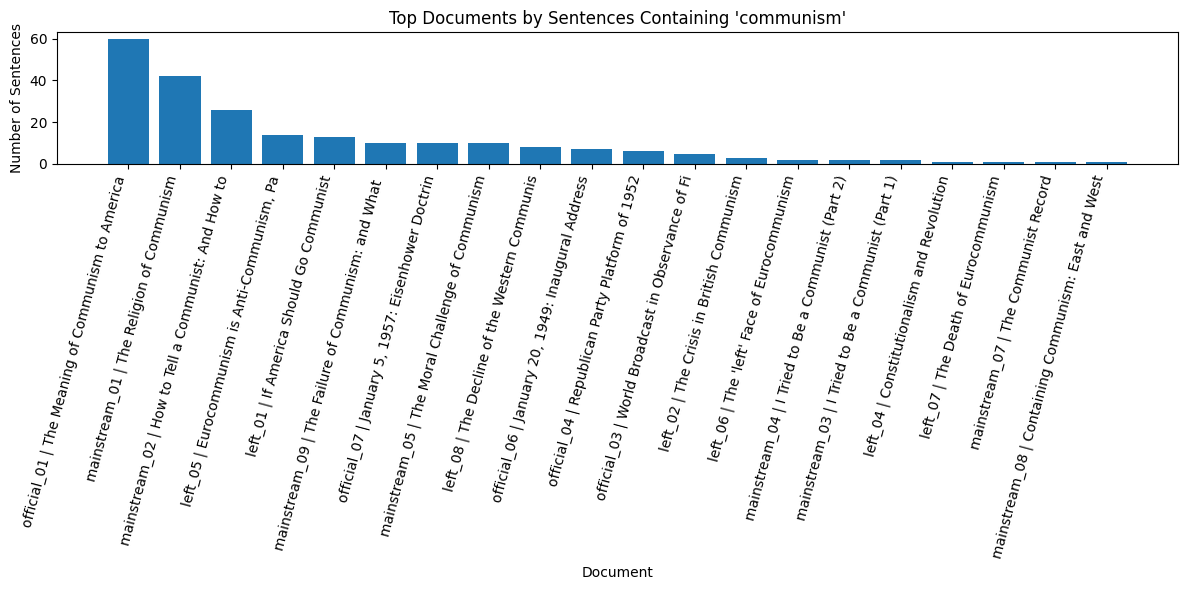

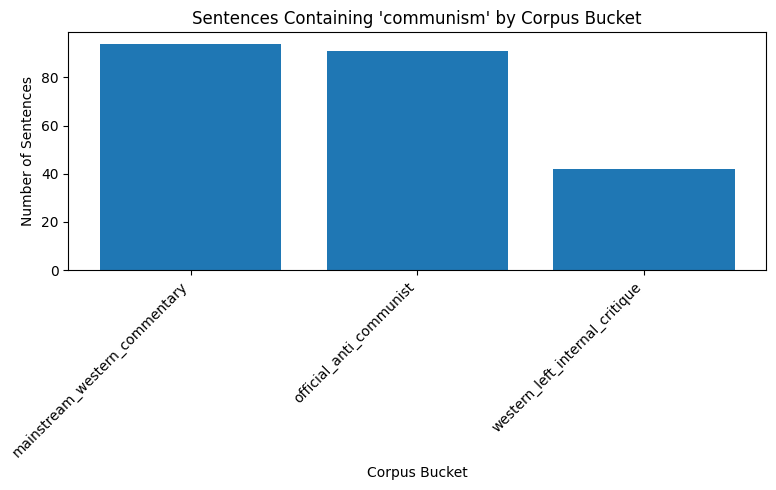


STEP 1 RESULTS

Concept selected: communism
Unit of analysis: complete sentence containing the word 'communism'

Total sentences containing the concept: 227
Number of documents: 23
Number of sources: 4
Year range: 1931–1990

Initial pattern:
The corpus does not use 'communism' evenly across documents. A small number of documents contain many repeated uses of the concept, suggesting that some texts treat communism as a central object of explanation, critique, or political argument rather than as a passing reference. The bucket distribution also shows whether official anti-communist, mainstream commentary, or left-internal critique texts dominate the concept's usage.



In [24]:
# =========================
# Cell 3. Step 1: Concept and data preparation
# =========================

concept = "communism"
unit_of_analysis = "complete sentence containing the word 'communism'"

n_sentences = len(df)
n_docs = df["doc_id"].nunique()
n_sources = df["source"].nunique()
n_buckets = df["bucket"].nunique()
year_min = int(df["year"].min()) if "year" in df.columns and df["year"].notna().any() else None
year_max = int(df["year"].max()) if "year" in df.columns and df["year"].notna().any() else None

summary = pd.DataFrame([{
    "concept": concept,
    "unit_of_analysis": unit_of_analysis,
    "total_occurrence_sentences": n_sentences,
    "unique_documents": n_docs,
    "unique_sources": n_sources,
    "unique_buckets": n_buckets,
    "year_min": year_min,
    "year_max": year_max,
}])

display(summary)
summary.to_csv(TABLE_DIR / "table_01_dataset_summary.csv", index=False, encoding="utf-8-sig")

# Distribution by document
doc_dist = (
    df.groupby(["doc_id", "title", "year", "source", "bucket"])
      .size()
      .reset_index(name="n_communism_sentences")
      .sort_values("n_communism_sentences", ascending=False)
)

display(doc_dist.head(20))
doc_dist.to_csv(TABLE_DIR / "table_02_distribution_by_document.csv", index=False, encoding="utf-8-sig")

# Distribution by bucket
bucket_dist = (
    df.groupby("bucket")
      .size()
      .reset_index(name="n_communism_sentences")
      .sort_values("n_communism_sentences", ascending=False)
)

display(bucket_dist)
bucket_dist.to_csv(TABLE_DIR / "table_03_distribution_by_bucket.csv", index=False, encoding="utf-8-sig")

# Distribution by year
year_dist = (
    df.dropna(subset=["year"])
      .groupby("year")
      .size()
      .reset_index(name="n_communism_sentences")
      .sort_values("year")
)

display(year_dist.head())
year_dist.to_csv(TABLE_DIR / "table_04_distribution_by_year.csv", index=False, encoding="utf-8-sig")

# Figure 1: occurrences by document, top 20
top_docs = doc_dist.head(20).copy()
top_docs["doc_label"] = top_docs["doc_id"] + " | " + top_docs["title"].str.slice(0, 35)

plt.figure(figsize=(12, 6))
plt.bar(top_docs["doc_label"], top_docs["n_communism_sentences"])
plt.title("Top Documents by Sentences Containing 'communism'")
plt.xlabel("Document")
plt.ylabel("Number of Sentences")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01_occurrences_by_document.png", dpi=200)
plt.show()



# Figure 2: occurrences by bucket
plt.figure(figsize=(8, 5))
plt.bar(bucket_dist["bucket"], bucket_dist["n_communism_sentences"])
plt.title("Sentences Containing 'communism' by Corpus Bucket")
plt.xlabel("Corpus Bucket")
plt.ylabel("Number of Sentences")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_03_occurrences_by_bucket.png", dpi=200)
plt.show()

step1_text = f"""
STEP 1 RESULTS

Concept selected: {concept}
Unit of analysis: {unit_of_analysis}

Total sentences containing the concept: {n_sentences}
Number of documents: {n_docs}
Number of sources: {n_sources}
Year range: {year_min}–{year_max}

Initial pattern:
The corpus does not use 'communism' evenly across documents. A small number of documents contain many repeated uses of the concept, suggesting that some texts treat communism as a central object of explanation, critique, or political argument rather than as a passing reference. The bucket distribution also shows whether official anti-communist, mainstream commentary, or left-internal critique texts dominate the concept's usage.
"""

print(step1_text)

with open(TEXT_DIR / "step1_data_preparation_summary.txt", "w", encoding="utf-8") as f:
    f.write(step1_text)

Running spaCy NER:   0%|          | 0/227 [00:00<?, ?it/s]

Number of entity mentions: 271


,sentence_id,doc_id,title,year,source,bucket,label,entity_text,entity_type,sentence
0,official_01__p00000__s000,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Threat,the United States,GPE,The major problem confronting the people of th...
1,official_01__p00000__s000,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Threat,the last half of the 20th century,DATE,The major problem confronting the people of th...
2,official_01__p00000__s005,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Threat,Americans,NORP,The time is long past when any significant num...
3,official_01__p00000__s008,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Threat,today,DATE,The danger today in our attitude toward commun...
4,official_01__p00000__s023,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Doctrine,more than 40 years,DATE,We must come to understand the weaknesses of c...
5,official_01__p00000__s042,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Threat,Communist,NORP,Now this theory of successive stages of develo...
6,official_01__p00000__s042,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Threat,Communist,NORP,Now this theory of successive stages of develo...
7,official_01__p00000__s045,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Threat,Communist,NORP,The fundamental belief of the Communist econom...
8,official_01__p00000__s045,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Threat,Communist,NORP,The fundamental belief of the Communist econom...
9,official_01__p00000__s049,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,System,Marx,PERSON,Marx and Engels could afford this praise for c...


,entity_type,count
0,NORP,78
1,ORG,52
2,GPE,51
3,DATE,22
4,PERSON,17
5,CARDINAL,16
6,LOC,14
7,ORDINAL,9
8,MONEY,5
9,LAW,2


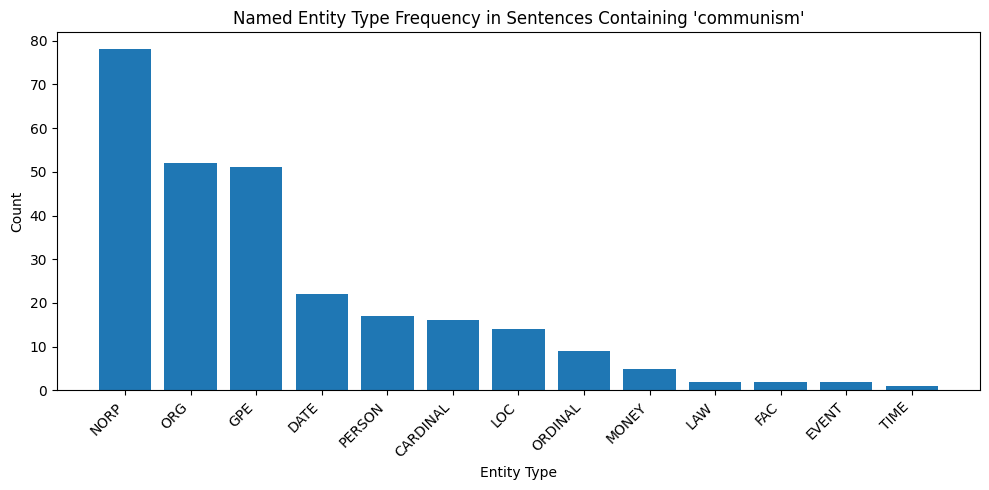

In [5]:
# =========================
# Cell 4. Step 2: Named Entity Recognition
# =========================

nlp = spacy.load("en_core_web_sm")

records = []

for i, row in tqdm(df.iterrows(), total=len(df), desc="Running spaCy NER"):
    doc = nlp(row["sentence"])
    for ent in doc.ents:
        records.append({
            "sentence_id": row["sentence_id"],
            "doc_id": row["doc_id"],
            "title": row["title"],
            "year": row["year"],
            "source": row["source"],
            "bucket": row["bucket"],
            "label": row["label"],
            "entity_text": ent.text,
            "entity_type": ent.label_,
            "sentence": row["sentence"],
        })

ent_df = pd.DataFrame(records)

print("Number of entity mentions:", len(ent_df))
display(ent_df.head(20))

ent_df.to_csv(TABLE_DIR / "table_05_all_named_entities.csv", index=False, encoding="utf-8-sig")

entity_type_freq = (
    ent_df["entity_type"]
    .value_counts()
    .reset_index()
)
entity_type_freq.columns = ["entity_type", "count"]

display(entity_type_freq)
entity_type_freq.to_csv(TABLE_DIR / "table_06_entity_type_frequency.csv", index=False, encoding="utf-8-sig")

# Figure: entity type frequency
plt.figure(figsize=(10, 5))
plt.bar(entity_type_freq["entity_type"], entity_type_freq["count"])
plt.title("Named Entity Type Frequency in Sentences Containing 'communism'")
plt.xlabel("Entity Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_04_entity_type_frequency.png", dpi=200)
plt.show()

,entity_type,entity_text,count
1,GPE,America,8
24,GPE,the United States,7
16,GPE,Russia,6
23,GPE,the Soviet Union,5
2,GPE,Britain,2
4,GPE,China,2
14,GPE,Japan,2
0,GPE,Albania,1
3,GPE,Chile,1
5,GPE,D.C.,1


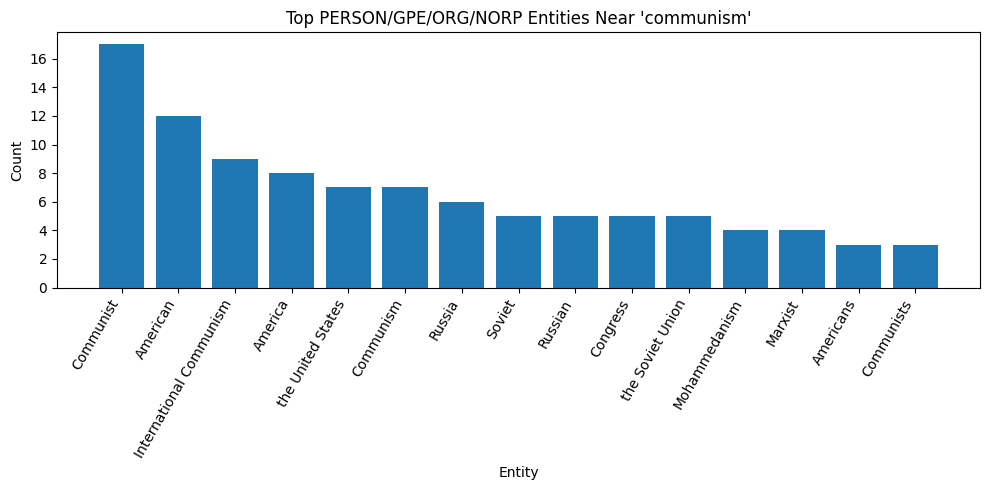

,entity_type,entity_text,doc_id,title,year,source,label,sentence,entity_count
15,GPE,America,official_06,"January 20, 1949: Inaugural Address",1949,Miller Center,Doctrine,"Truman January 20, 1949 Source National Archiv...",8
38,GPE,the United States,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,Threat,The major problem confronting the people of th...,7
30,GPE,Russia,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,System,For a long time after the establishment of the...,6
37,GPE,the Soviet Union,mainstream_09,The Failure of Communism: and What It Portends,1961,The Atlantic,System,"Above all, the vision of the Soviet Union as t...",5
16,GPE,Britain,left_08,The Decline of the Western Communist Parties,1990,Marxists Internet Archive,System,"In Britain the editor of Marxism Today , the m...",2
18,GPE,China,mainstream_09,The Failure of Communism: and What It Portends,1961,The Atlantic,System,"Meanwhile, the U.S.S.R., China, and the satell...",2
28,GPE,Japan,left_01,If America Should Go Communist,1934,Marxists Internet Archive,System,"Japan, Great Britain and the other capitalisti...",2
14,GPE,Albania,left_08,The Decline of the Western Communist Parties,1990,Marxists Internet Archive,System,"Premtaj, Stalinism and Communism in Albania , ...",1
17,GPE,Chile,left_08,The Decline of the Western Communist Parties,1990,Marxists Internet Archive,System,"Chile’s return to democracy in March, combined...",1
19,GPE,D.C.,official_06,"January 20, 1949: Inaugural Address",1949,Miller Center,Doctrine,"Truman January 20, 1949 Source National Archiv...",1


,label,entity_type,count
1,Doctrine,NORP,24
2,Doctrine,ORG,15
0,Doctrine,GPE,9
3,Doctrine,PERSON,2
5,System,NORP,41
4,System,GPE,33
6,System,ORG,24
7,System,PERSON,14
9,Threat,NORP,13
10,Threat,ORG,13



STEP 2 RESULTS

Focus entity types: PERSON, GPE, ORG, and NORP.

Interpretive direction:
These entity types are useful because the project asks whether the meaning of 'communism' is associated with particular people, institutions, places, or political groups. In this corpus, NER helps identify whether 'communism' is attached to geopolitical actors, ideological figures, political organizations, or national groups.

Limitation:
NER can identify surface entities, but it does not by itself explain whether the sentence treats communism as doctrine, system, or threat. It also may miss historically specific expressions, confuse political labels with organizations, or fail on older prose and long sentences.



In [6]:
# =========================
# Cell 5. Step 2: Focus entities and co-occurrence examples
# =========================

focus_types = ["PERSON", "GPE", "ORG", "NORP"]

focus_ent_df = ent_df[ent_df["entity_type"].isin(focus_types)].copy()

top_entities = (
    focus_ent_df.groupby(["entity_type", "entity_text"])
    .size()
    .reset_index(name="count")
    .sort_values(["entity_type", "count"], ascending=[True, False])
)

display(top_entities.head(50))
top_entities.to_csv(TABLE_DIR / "table_07_top_focus_entities.csv", index=False, encoding="utf-8-sig")

# Top 15 entities overall among focus types
top15_focus = (
    focus_ent_df["entity_text"]
    .value_counts()
    .head(15)
    .reset_index()
)
top15_focus.columns = ["entity_text", "count"]

plt.figure(figsize=(10, 5))
plt.bar(top15_focus["entity_text"], top15_focus["count"])
plt.title("Top PERSON/GPE/ORG/NORP Entities Near 'communism'")
plt.xlabel("Entity")
plt.ylabel("Count")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_05_top_person_gpe_org_norp_entities.png", dpi=200)
plt.show()

# Examples showing concept-entity co-occurrence
example_rows = []
for etype in focus_types:
    sub = focus_ent_df[focus_ent_df["entity_type"] == etype]
    for ent_text, g in sub.groupby("entity_text"):
        row = g.iloc[0]
        example_rows.append({
            "entity_type": etype,
            "entity_text": ent_text,
            "doc_id": row["doc_id"],
            "title": row["title"],
            "year": row["year"],
            "source": row["source"],
            "label": row["label"],
            "sentence": row["sentence"],
        })

entity_examples = pd.DataFrame(example_rows)
entity_examples["entity_count"] = entity_examples["entity_text"].map(focus_ent_df["entity_text"].value_counts())
entity_examples = entity_examples.sort_values(["entity_type", "entity_count"], ascending=[True, False])

display(entity_examples.head(40))
entity_examples.to_csv(TABLE_DIR / "table_08_entity_cooccurrence_examples.csv", index=False, encoding="utf-8-sig")

# Entity type by weak label
entity_by_label = (
    focus_ent_df.groupby(["label", "entity_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["label", "count"], ascending=[True, False])
)

display(entity_by_label)
entity_by_label.to_csv(TABLE_DIR / "table_09_entity_type_by_label.csv", index=False, encoding="utf-8-sig")

step2_text = """
STEP 2 RESULTS

Focus entity types: PERSON, GPE, ORG, and NORP.

Interpretive direction:
These entity types are useful because the project asks whether the meaning of 'communism' is associated with particular people, institutions, places, or political groups. In this corpus, NER helps identify whether 'communism' is attached to geopolitical actors, ideological figures, political organizations, or national groups.

Limitation:
NER can identify surface entities, but it does not by itself explain whether the sentence treats communism as doctrine, system, or threat. It also may miss historically specific expressions, confuse political labels with organizations, or fail on older prose and long sentences.
"""

print(step2_text)

with open(TEXT_DIR / "step2_ner_summary.txt", "w", encoding="utf-8") as f:
    f.write(step2_text)

In [7]:
# =========================
# Cell 6. Step 3: BERT embeddings
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(str(BERT_DIR), local_files_only=True)
bert_model = AutoModel.from_pretrained(str(BERT_DIR), local_files_only=True).to(device)
bert_model.eval()

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

sentences = df["sentence"].tolist()
batch_size = 16
embeddings = []

with torch.no_grad():
    for start in tqdm(range(0, len(sentences), batch_size), desc="Embedding sentences with BERT"):
        batch = sentences[start:start+batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        ).to(device)

        out = bert_model(**enc)
        emb = mean_pool(out.last_hidden_state, enc["attention_mask"])
        embeddings.append(emb.cpu().numpy())

X = np.vstack(embeddings)

print("Embedding shape:", X.shape)

np.save(OUT_DIR / "bert_sentence_embeddings.npy", X)
print("Saved:", OUT_DIR / "bert_sentence_embeddings.npy")

Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: /root/autodl-tmp/ids570_term_project/models/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding sentences with BERT:   0%|          | 0/15 [00:00<?, ?it/s]

Embedding shape: (227, 768)
Saved: /root/autodl-tmp/ids570_term_project/final_outputs/bert_sentence_embeddings.npy


PCA explained variance ratio: [0.07189449 0.05634123]


,k,silhouette
0,2,0.045793
1,3,0.031492
2,4,0.034588
3,5,0.041672
4,6,0.019546


Best k by silhouette: 2
Saved clustered sentences: /root/autodl-tmp/ids570_term_project/final_outputs/tables/table_11_sentences_with_bert_clusters.csv


,bert_cluster,count
0,0,117
1,1,110


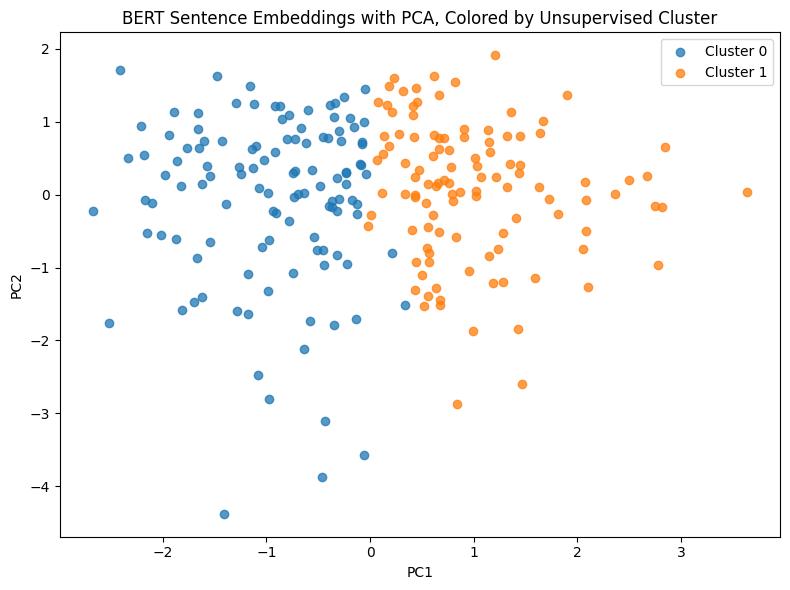

,bert_cluster,rank_near_center,distance_to_center,doc_id,title,year,source,bucket,sentence
0,0,1,2.840049,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,IV In spite of the many obvious similarities b...
1,0,2,3.037663,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,The fundamental belief of the Communist econom...
2,0,3,3.243788,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Now this theory of successive stages of develo...
3,0,4,3.281492,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,Ostensibly communism makes no metaphysical pre...
4,0,5,3.340379,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,In Russia a whole nation was still in a state ...
5,0,6,3.343007,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,The dogma of communism regarding the inevitabi...
6,0,7,3.376729,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,Historians allege that economic wars have repl...
7,0,8,3.385326,mainstream_02,How to Tell a Communist: And How to Beat Him,1939,The Atlantic,mainstream_western_commentary,The fallacy in Communism is not in the ultimat...
8,0,9,3.389502,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,From this perspective the conflict between com...
9,0,10,3.411128,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Then again we must remember that in the Commun...



STEP 3 RESULTS

BERT model: local bert-base-uncased
Embedding method: mean pooling over the final hidden states.
Visualization method: PCA to two dimensions.
Clustering method: KMeans.
Cluster selection method: silhouette score over k = 2 to 6.
Best k by silhouette score: 2.





In [14]:
# =========================
# Cell 7. Step 3: BERT unsupervised clustering and visualization
# =========================

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert len(df) == X.shape[0], "df and BERT embeddings X are misaligned."

# ------------------------------------------------------------
# 1. PCA visualization
# ------------------------------------------------------------
pca = PCA(n_components=2, random_state=3407)
X_pca = pca.fit_transform(X)

pca_df = df.copy()
pca_df["pc1"] = X_pca[:, 0]
pca_df["pc2"] = X_pca[:, 1]

print("PCA explained variance ratio:", pca.explained_variance_ratio_)

# ------------------------------------------------------------
# 2. Choose k by silhouette score
# BERT clustering is fully unsupervised.
# Weak labels are NOT used here.
# ------------------------------------------------------------
cluster_scores = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=3407, n_init=20)
    pred = km.fit_predict(X)
    score = silhouette_score(X, pred)
    cluster_scores.append({
        "k": k,
        "silhouette": score
    })

cluster_score_df = pd.DataFrame(cluster_scores)

display(cluster_score_df)

cluster_score_df.to_csv(
    TABLE_DIR / "table_10_bert_cluster_silhouette_scores.csv",
    index=False,
    encoding="utf-8-sig"
)

best_k = int(
    cluster_score_df
    .sort_values("silhouette", ascending=False)
    .iloc[0]["k"]
)

print("Best k by silhouette:", best_k)

# ------------------------------------------------------------
# 3. Final KMeans with best_k
# ------------------------------------------------------------
kmeans = KMeans(n_clusters=best_k, random_state=3407, n_init=30)
clusters = kmeans.fit_predict(X)

df["bert_cluster"] = clusters
pca_df["bert_cluster"] = clusters

clustered_path = TABLE_DIR / "table_11_sentences_with_bert_clusters.csv"
df.to_csv(clustered_path, index=False, encoding="utf-8-sig")

print("Saved clustered sentences:", clustered_path)

# ------------------------------------------------------------
# 4. Cluster counts
# ------------------------------------------------------------
cluster_counts = (
    df["bert_cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = ["bert_cluster", "count"]

display(cluster_counts)

cluster_counts.to_csv(
    TABLE_DIR / "table_12_bert_cluster_counts.csv",
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 5. PCA figure colored ONLY by BERT cluster
# No weak-label PCA figure in the BERT section.
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

for c in sorted(pca_df["bert_cluster"].unique()):
    sub = pca_df[pca_df["bert_cluster"] == c]
    plt.scatter(
        sub["pc1"],
        sub["pc2"],
        label=f"Cluster {c}",
        alpha=0.75
    )

plt.title("BERT Sentence Embeddings with PCA, Colored by Unsupervised Cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_06_bert_pca_clusters.png", dpi=200)
plt.show()

# ------------------------------------------------------------
# 6. Representative examples near each cluster center
# ------------------------------------------------------------
examples = []

for c in sorted(df["bert_cluster"].unique()):
    idxs = np.where(clusters == c)[0]
    center = kmeans.cluster_centers_[c]
    dists = np.linalg.norm(X[idxs] - center, axis=1)
    nearest_order = idxs[np.argsort(dists)[:12]]

    for rank, idx in enumerate(nearest_order, start=1):
        row = df.iloc[idx]
        examples.append({
            "bert_cluster": c,
            "rank_near_center": rank,
            "distance_to_center": float(np.linalg.norm(X[idx] - center)),
            "doc_id": row["doc_id"],
            "title": row["title"],
            "year": row["year"],
            "source": row["source"],
            "bucket": row["bucket"],
            "sentence": row["sentence"],
        })

cluster_examples = pd.DataFrame(examples)

display(cluster_examples)

cluster_examples.to_csv(
    TABLE_DIR / "table_13_bert_cluster_representative_examples.csv",
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 7. Summary text
# ------------------------------------------------------------
step3_text = f"""
STEP 3 RESULTS

BERT model: local bert-base-uncased
Embedding method: mean pooling over the final hidden states.
Visualization method: PCA to two dimensions.
Clustering method: KMeans.
Cluster selection method: silhouette score over k = 2 to 6.
Best k by silhouette score: {best_k}.


"""

print(step3_text)

with open(TEXT_DIR / "step3_bert_summary.txt", "w", encoding="utf-8") as f:
    f.write(step3_text)

In [16]:
# =========================
# Cell 7B. Export BERT two-cluster sentence CSV for manual interpretation
# =========================

from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

assert len(df) == X.shape[0], "df and BERT embeddings X are misaligned."

# Force BERT into 2 unsupervised clusters for interpretation
kmeans_2 = KMeans(n_clusters=2, random_state=3407, n_init=30)
bert_cluster_2 = kmeans_2.fit_predict(X)

df_bert2 = df.copy()
df_bert2["bert_cluster_2"] = bert_cluster_2

# Distance to each cluster center
centers = kmeans_2.cluster_centers_
dist_to_0 = np.linalg.norm(X - centers[0], axis=1)
dist_to_1 = np.linalg.norm(X - centers[1], axis=1)

df_bert2["dist_to_cluster_0"] = dist_to_0
df_bert2["dist_to_cluster_1"] = dist_to_1
df_bert2["cluster_margin"] = np.abs(dist_to_0 - dist_to_1)

# Rank by how representative the sentence is within its own cluster
df_bert2["distance_to_own_cluster"] = np.where(
    df_bert2["bert_cluster_2"] == 0,
    df_bert2["dist_to_cluster_0"],
    df_bert2["dist_to_cluster_1"]
)

df_bert2["representative_rank_in_cluster"] = (
    df_bert2
    .groupby("bert_cluster_2")["distance_to_own_cluster"]
    .rank(method="first", ascending=True)
    .astype(int)
)

# Version 1: full CSV with source info, but WITHOUT weak label
# 用这个发给我判断 BERT 到底怎么分，避免被弱标签干扰
bert2_blind_cols = [
    "bert_cluster_2",
    "representative_rank_in_cluster",
    "distance_to_own_cluster",
    "cluster_margin",
    "sentence_id",
    "doc_id",
    "title",
    "year",
    "source",
    "bucket",
    "sentence",
]

bert2_blind = (
    df_bert2[bert2_blind_cols]
    .sort_values(["bert_cluster_2", "representative_rank_in_cluster"])
    .reset_index(drop=True)
)

blind_path = TABLE_DIR / "table_15_bert_two_clusters_for_manual_naming_BLIND.csv"
bert2_blind.to_csv(blind_path, index=False, encoding="utf-8-sig")

# Version 2: full CSV with weak label included for later comparison
# 这个先不要用来命名，可以之后做对照
bert2_with_label_cols = bert2_blind_cols[:]
if "label" in df_bert2.columns:
    bert2_with_label_cols.insert(1, "label")

bert2_with_label = (
    df_bert2[bert2_with_label_cols]
    .sort_values(["bert_cluster_2", "representative_rank_in_cluster"])
    .reset_index(drop=True)
)

with_label_path = TABLE_DIR / "table_16_bert_two_clusters_with_weak_label_REFERENCE.csv"
bert2_with_label.to_csv(with_label_path, index=False, encoding="utf-8-sig")

# Save a short count table
bert2_counts = (
    df_bert2["bert_cluster_2"]
    .value_counts()
    .sort_index()
    .reset_index()
)
bert2_counts.columns = ["bert_cluster_2", "n_sentences"]

counts_path = TABLE_DIR / "table_17_bert_two_cluster_counts.csv"
bert2_counts.to_csv(counts_path, index=False, encoding="utf-8-sig")

display(bert2_counts)

print("Saved blind CSV for manual naming:")
print(blind_path)

print("\nSaved reference CSV with weak labels:")
print(with_label_path)

print("\nSaved counts:")
print(counts_path)

print("\nPreview: most representative examples from each BERT cluster")
for c in sorted(df_bert2["bert_cluster_2"].unique()):
    print("=" * 100)
    print(f"BERT CLUSTER {c}")
    print("=" * 100)
    sub = bert2_blind[bert2_blind["bert_cluster_2"] == c].head(10)
    display(sub[[
        "bert_cluster_2",
        "representative_rank_in_cluster",
        "doc_id",
        "year",
        "title",
        "sentence"
    ]])

,bert_cluster_2,n_sentences
0,0,117
1,1,110


Saved blind CSV for manual naming:
/root/autodl-tmp/ids570_term_project/final_outputs/tables/table_15_bert_two_clusters_for_manual_naming_BLIND.csv

Saved reference CSV with weak labels:
/root/autodl-tmp/ids570_term_project/final_outputs/tables/table_16_bert_two_clusters_with_weak_label_REFERENCE.csv

Saved counts:
/root/autodl-tmp/ids570_term_project/final_outputs/tables/table_17_bert_two_cluster_counts.csv

Preview: most representative examples from each BERT cluster
BERT CLUSTER 0


,bert_cluster_2,representative_rank_in_cluster,doc_id,year,title,sentence
0,0,1,mainstream_01,1931,The Religion of Communism,IV In spite of the many obvious similarities b...
1,0,2,official_01,1956,The Meaning of Communism to Americans: Study P...,The fundamental belief of the Communist econom...
2,0,3,official_01,1956,The Meaning of Communism to Americans: Study P...,Now this theory of successive stages of develo...
3,0,4,mainstream_01,1931,The Religion of Communism,Ostensibly communism makes no metaphysical pre...
4,0,5,mainstream_01,1931,The Religion of Communism,In Russia a whole nation was still in a state ...
5,0,6,mainstream_01,1931,The Religion of Communism,The dogma of communism regarding the inevitabi...
6,0,7,mainstream_01,1931,The Religion of Communism,Historians allege that economic wars have repl...
7,0,8,mainstream_02,1939,How to Tell a Communist: And How to Beat Him,The fallacy in Communism is not in the ultimat...
8,0,9,mainstream_01,1931,The Religion of Communism,From this perspective the conflict between com...
9,0,10,official_01,1956,The Meaning of Communism to Americans: Study P...,Then again we must remember that in the Commun...


BERT CLUSTER 1


,bert_cluster_2,representative_rank_in_cluster,doc_id,year,title,sentence
117,1,1,left_05,1978,"Eurocommunism is Anti-Communism, Part 1","Like Browder, Tito, Togliatti, etc., who preac..."
118,1,2,mainstream_01,1931,The Religion of Communism,What seems important is that the religion of c...
119,1,3,official_03,1958,World Broadcast in Observance of Fifteenth Ann...,"My proposals fit right in with this purpose, f..."
120,1,4,official_01,1956,The Meaning of Communism to Americans: Study P...,(There is an incredibly tortured literature ab...
121,1,5,left_05,1978,"Eurocommunism is Anti-Communism, Part 1","Not only Browderism, but also Mao Zedong thoug..."
122,1,6,left_01,1934,If America Should Go Communist,"As a matter of fact, the victory of communism ..."
123,1,7,left_01,1934,If America Should Go Communist,"* * * August 17, 1934 Should America go commun..."
124,1,8,official_01,1956,The Meaning of Communism to Americans: Study P...,Among the conclusions about the future that we...
125,1,9,official_07,1957,"January 5, 1957: Eisenhower Doctrine","On the other hand many, if not all, of the nat..."
126,1,10,left_01,1934,If America Should Go Communist,* * * Introduction from Fourth International T...


Saved named BERT cluster table:
/root/autodl-tmp/ids570_term_project/final_outputs/tables/table_18_bert_clusters_named.csv


,bert_cluster_name,n_sentences
0,Doctrinal Imagination,117
1,Geopolitical Mobilization,110


,bert_cluster_2,bert_cluster_name,label,representative_rank_in_cluster,doc_id,title,year,source,bucket,sentence
127,0,Doctrinal Imagination,Doctrine,1,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,IV In spite of the many obvious similarities b...
19,0,Doctrinal Imagination,Threat,2,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,The fundamental belief of the Communist econom...
17,0,Doctrinal Imagination,Threat,3,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Now this theory of successive stages of develo...
128,0,Doctrinal Imagination,Doctrine,4,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,Ostensibly communism makes no metaphysical pre...
100,0,Doctrinal Imagination,System,5,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,In Russia a whole nation was still in a state ...
108,0,Doctrinal Imagination,Doctrine,6,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,The dogma of communism regarding the inevitabi...
109,0,Doctrinal Imagination,System,7,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,Historians allege that economic wars have repl...
153,0,Doctrinal Imagination,Doctrine,8,mainstream_02,How to Tell a Communist: And How to Beat Him,1939,The Atlantic,mainstream_western_commentary,The fallacy in Communism is not in the ultimat...
116,0,Doctrinal Imagination,Doctrine,9,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,From this perspective the conflict between com...
50,0,Doctrinal Imagination,Doctrine,10,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Then again we must remember that in the Commun...


bucket,mainstream_western_commentary,official_anti_communist,western_left_internal_critique
bert_cluster_name,,,
Doctrinal Imagination,58,52,7
Geopolitical Mobilization,36,39,35


source,American Presidency Project,Marxists Internet Archive,Miller Center,The Atlantic
bert_cluster_name,,,,
Doctrinal Imagination,45,7,7,58
Geopolitical Mobilization,27,35,12,36


,bert_cluster_name,count,min,max,mean,median
0,Doctrinal Imagination,117,1931,1979,1946.461538,1951.0
1,Geopolitical Mobilization,110,1931,1990,1955.245455,1956.0


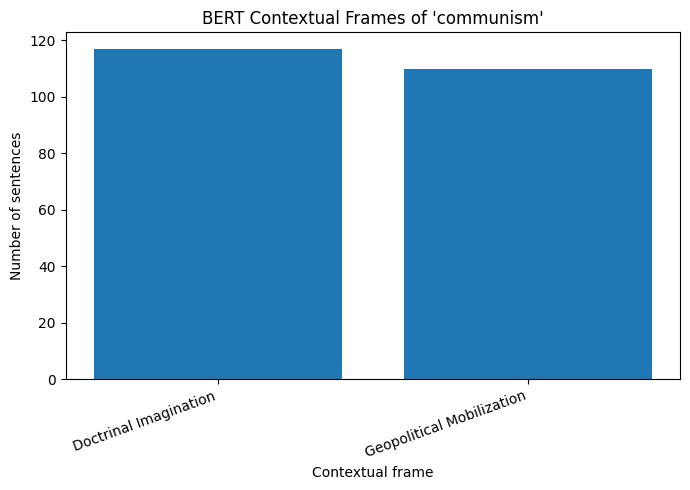


.



In [18]:
# =========================
# Cell 7C. Name BERT clusters after manual interpretation
# =========================

# Based on manual review of table_15_bert_two_clusters_for_manual_naming_BLIND.csv:
# Cluster 0 = Doctrinal Imagination
# Cluster 1 = Geopolitical Mobilization

bert_cluster_name_map = {
    0: "Doctrinal Imagination",
    1: "Geopolitical Mobilization",
}

# If you used bert_cluster_2 in Cell 7B, copy it into df
if "bert_cluster_2" in df_bert2.columns:
    df["bert_cluster_2"] = df_bert2["bert_cluster_2"].values
else:
    raise ValueError("df_bert2 with bert_cluster_2 not found. Please run Cell 7B first.")

df["bert_cluster_name"] = df["bert_cluster_2"].map(bert_cluster_name_map)

# Save final BERT interpreted table
bert_named_path = TABLE_DIR / "table_18_bert_clusters_named.csv"
df.to_csv(bert_named_path, index=False, encoding="utf-8-sig")

print("Saved named BERT cluster table:")
print(bert_named_path)

# Counts by named BERT cluster
bert_name_counts = (
    df["bert_cluster_name"]
    .value_counts()
    .reset_index()
)

bert_name_counts.columns = ["bert_cluster_name", "n_sentences"]

display(bert_name_counts)

bert_name_counts.to_csv(
    TABLE_DIR / "table_19_bert_cluster_name_counts.csv",
    index=False,
    encoding="utf-8-sig"
)

# Representative examples by named cluster
bert_named_examples = (
    df_bert2.copy()
    .assign(bert_cluster_name=lambda x: x["bert_cluster_2"].map(bert_cluster_name_map))
    .sort_values(["bert_cluster_2", "representative_rank_in_cluster"])
)

example_cols = [
    "bert_cluster_2",
    "bert_cluster_name",
    "representative_rank_in_cluster",
    "doc_id",
    "title",
    "year",
    "source",
    "bucket",
    "sentence",
]

if "label" in bert_named_examples.columns:
    example_cols.insert(2, "label")

bert_named_examples = bert_named_examples[example_cols]

display(bert_named_examples.groupby("bert_cluster_name").head(10))

bert_named_examples.to_csv(
    TABLE_DIR / "table_20_bert_named_cluster_representative_examples.csv",
    index=False,
    encoding="utf-8-sig"
)

# BERT cluster name by source/bucket/year
bert_bucket_tab = pd.crosstab(df["bert_cluster_name"], df["bucket"])
bert_source_tab = pd.crosstab(df["bert_cluster_name"], df["source"])
bert_year_summary = (
    df.groupby("bert_cluster_name")["year"]
    .agg(["count", "min", "max", "mean", "median"])
    .reset_index()
)

display(bert_bucket_tab)
display(bert_source_tab)
display(bert_year_summary)

bert_bucket_tab.to_csv(TABLE_DIR / "table_21_bert_named_cluster_by_bucket.csv", encoding="utf-8-sig")
bert_source_tab.to_csv(TABLE_DIR / "table_22_bert_named_cluster_by_source.csv", encoding="utf-8-sig")
bert_year_summary.to_csv(TABLE_DIR / "table_23_bert_named_cluster_year_summary.csv", index=False, encoding="utf-8-sig")

# Optional figure: named BERT cluster distribution
plt.figure(figsize=(7, 5))
plt.bar(bert_name_counts["bert_cluster_name"], bert_name_counts["n_sentences"])
plt.title("BERT Contextual Frames of 'communism'")
plt.xlabel("Contextual frame")
plt.ylabel("Number of sentences")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_07_bert_named_cluster_counts.png", dpi=200)
plt.show()

step3_named_text = """
.
"""

print(step3_named_text)

with open(TEXT_DIR / "step3_bert_cluster_names.txt", "w", encoding="utf-8") as f:
    f.write(step3_named_text)

In [21]:
# =========================
# Reload updated weak-label CSV
# =========================

import pandas as pd

INPUT_CSV = ROOT / "outputs" / "communism_sentences.csv"

df_new = pd.read_csv(INPUT_CSV)

# Basic standardization
df_new["sentence"] = df_new["sentence"].astype(str)
df_new["label"] = df_new["label"].astype(str).str.strip()
df_new["doc_id"] = df_new["doc_id"].astype(str)
df_new["title"] = df_new["title"].astype(str)
df_new["bucket"] = df_new["bucket"].astype(str)
df_new["source"] = df_new["source"].astype(str)

if "year" in df_new.columns:
    df_new["year"] = pd.to_numeric(df_new["year"], errors="coerce")

print("Reloaded:", df_new.shape)
print("\nNew label distribution:")
print(df_new["label"].value_counts())

display(df_new.head(10))

# Preserve BERT cluster names if you already ran Cell 7B/7C
# Assumes row order and sentence_id are unchanged.
keep_cols = []
for col in ["bert_cluster_2", "bert_cluster_name", "bert_cluster"]:
    if col in df.columns:
        keep_cols.append(col)

if keep_cols:
    old_cluster_info = df[["sentence_id"] + keep_cols].copy()
    df = df_new.merge(old_cluster_info, on="sentence_id", how="left")
    print("\nPreserved old BERT columns:", keep_cols)
else:
    df = df_new.copy()
    print("\nNo old BERT columns found. df reloaded only.")

print("\nCurrent df label distribution:")
print(df["label"].value_counts())

display(df.head(10))

Reloaded: (227, 13)

New label distribution:
label
Hostile        102
Neutral         79
Sympathetic     46
Name: count, dtype: int64


,sentence_id,doc_id,bucket,year,source,title,paragraph_idx,sentence_in_paragraph_idx,sentence,sentence_char_len,concept,label,label_note
0,official_01__p00000__s000,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,0,The major problem confronting the people of th...,230,communism,Hostile,"negative/threat cue: \bthreat\b, \bmilitant\b"
1,official_01__p00000__s001,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,1,A major weakness in this struggle is lack of a...,127,communism,Hostile,"negative/threat cue: \bstruggle\b, \bchallenge\b"
2,official_01__p00000__s004,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,4,The question is not one of being for or agains...,58,communism,Hostile,negative/threat cue: \bagainst\ communism\b
3,official_01__p00000__s005,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,5,The time is long past when any significant num...,121,communism,Hostile,official anti-communist context
4,official_01__p00000__s006,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,6,Few can still believe that communism is simply...,218,communism,Hostile,negative/threat cue: \bthreat\b
5,official_01__p00000__s008,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,8,The danger today in our attitude toward commun...,78,communism,Hostile,negative/threat cue: \bdanger\b
6,official_01__p00000__s009,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,9,It lies in the fact that we have come to abhor...,127,communism,Neutral,descriptive official explanation: \bunderstand...
7,official_01__p00000__s019,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,19,We cannot be content with simply an intuition ...,70,communism,Hostile,negative/threat cue: \bwrong\b
8,official_01__p00000__s020,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,20,It is not enough to rest our case alone on the...,139,communism,Hostile,"negative/threat cue: \bdenies\b, \benslaves\b,..."
9,official_01__p00000__s023,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,23,We must come to understand the weaknesses of c...,346,communism,Hostile,"negative/threat cue: \bblight\b, \bfailed\b"



Preserved old BERT columns: ['bert_cluster_2', 'bert_cluster_name', 'bert_cluster']

Current df label distribution:
label
Hostile        102
Neutral         79
Sympathetic     46
Name: count, dtype: int64


,sentence_id,doc_id,bucket,year,source,title,paragraph_idx,sentence_in_paragraph_idx,sentence,sentence_char_len,concept,label,label_note,bert_cluster_2,bert_cluster_name,bert_cluster
0,official_01__p00000__s000,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,0,The major problem confronting the people of th...,230,communism,Hostile,"negative/threat cue: \bthreat\b, \bmilitant\b",1,Geopolitical Mobilization,1
1,official_01__p00000__s001,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,1,A major weakness in this struggle is lack of a...,127,communism,Hostile,"negative/threat cue: \bstruggle\b, \bchallenge\b",0,Doctrinal Imagination,0
2,official_01__p00000__s004,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,4,The question is not one of being for or agains...,58,communism,Hostile,negative/threat cue: \bagainst\ communism\b,0,Doctrinal Imagination,0
3,official_01__p00000__s005,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,5,The time is long past when any significant num...,121,communism,Hostile,official anti-communist context,1,Geopolitical Mobilization,1
4,official_01__p00000__s006,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,6,Few can still believe that communism is simply...,218,communism,Hostile,negative/threat cue: \bthreat\b,0,Doctrinal Imagination,0
5,official_01__p00000__s008,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,8,The danger today in our attitude toward commun...,78,communism,Hostile,negative/threat cue: \bdanger\b,0,Doctrinal Imagination,0
6,official_01__p00000__s009,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,9,It lies in the fact that we have come to abhor...,127,communism,Neutral,descriptive official explanation: \bunderstand...,0,Doctrinal Imagination,0
7,official_01__p00000__s019,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,19,We cannot be content with simply an intuition ...,70,communism,Hostile,negative/threat cue: \bwrong\b,0,Doctrinal Imagination,0
8,official_01__p00000__s020,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,20,It is not enough to rest our case alone on the...,139,communism,Hostile,"negative/threat cue: \bdenies\b, \benslaves\b,...",0,Doctrinal Imagination,0
9,official_01__p00000__s023,official_01,official_anti_communist,1956,American Presidency Project,The Meaning of Communism to Americans: Study P...,0,23,We must come to understand the weaknesses of c...,346,communism,Hostile,"negative/threat cue: \bblight\b, \bfailed\b",1,Geopolitical Mobilization,1


Classification data shape: (227, 16)

Label distribution:
label
Hostile        102
Neutral         79
Sympathetic     46
Name: count, dtype: int64


,label,count
0,Hostile,102
1,Neutral,79
2,Sympathetic,46



Train size: 170
Test size: 57

Train label distribution:
label
Hostile        76
Neutral        59
Sympathetic    35
Name: count, dtype: int64

Test label distribution:
label
Hostile        26
Neutral        20
Sympathetic    11
Name: count, dtype: int64

Accuracy: 0.614
Macro-F1: 0.5556


,label,precision,recall,f1-score,support
0,Hostile,0.642857,0.692308,0.666667,26.000000
1,Neutral,0.636364,0.700000,0.666667,20.000000
2,Sympathetic,0.428571,0.272727,0.333333,11.000000
3,accuracy,0.614035,0.614035,0.614035,0.614035
4,macro avg,0.569264,0.555012,0.555556,57.000000
5,weighted avg,0.599225,0.614035,0.602339,57.000000


,pred_Hostile,pred_Neutral,pred_Sympathetic
true_Hostile,18,5,3
true_Neutral,5,14,1
true_Sympathetic,5,3,3


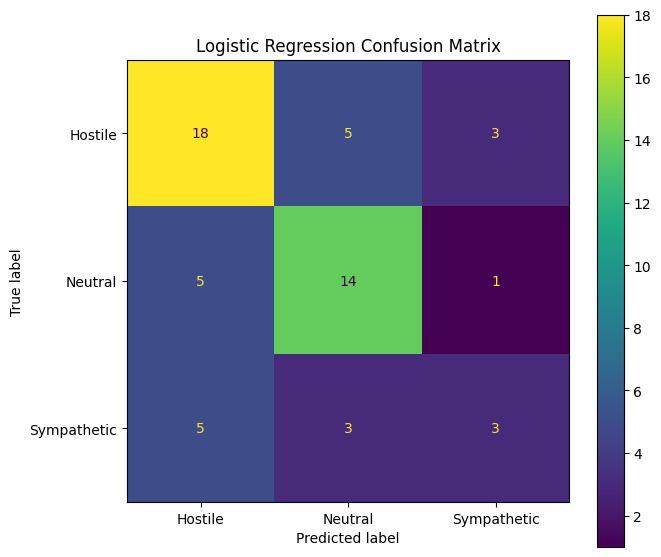

Saved model:
/root/autodl-tmp/ids570_term_project/final_outputs/models/logistic_regression_tfidf_pipeline.joblib


In [22]:
# =========================
# Cell 8. Step 4: Supervised classification with logistic regression
# Three stance labels: Hostile / Neutral / Sympathetic
# =========================

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import joblib
import pandas as pd
import matplotlib.pyplot as plt

clf_df = df[df["label"].notna() & (df["label"].astype(str).str.len() > 0)].copy()

print("Classification data shape:", clf_df.shape)
print("\nLabel distribution:")
print(clf_df["label"].value_counts())

label_dist = clf_df["label"].value_counts().reset_index()
label_dist.columns = ["label", "count"]

display(label_dist)

label_dist.to_csv(
    TABLE_DIR / "table_24_label_distribution.csv",
    index=False,
    encoding="utf-8-sig"
)

X_text = clf_df["sentence"].astype(str)
y = clf_df["label"].astype(str)

# 关键改动：同时保存 train/test index，方便 Cell 9 错误分析追踪出处
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X_text,
    y,
    clf_df.index,
    test_size=0.25,
    random_state=3407,
    stratify=y
)

print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

# 保存训练/测试划分
split_df = clf_df.copy()
split_df["split"] = "unused"
split_df.loc[train_idx, "split"] = "train"
split_df.loc[test_idx, "split"] = "test"

split_df.to_csv(
    TABLE_DIR / "table_24b_train_test_split.csv",
    index=False,
    encoding="utf-8-sig"
)

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("logreg", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=3407
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("\nAccuracy:", round(acc, 4))
print("Macro-F1:", round(macro_f1, 4))

report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index": "label"})

display(report_df)

report_df.to_csv(
    TABLE_DIR / "table_25_classification_report.csv",
    index=False,
    encoding="utf-8-sig"
)

labels_sorted = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{x}" for x in labels_sorted],
    columns=[f"pred_{x}" for x in labels_sorted]
)

display(cm_df)

cm_df.to_csv(
    TABLE_DIR / "table_26_confusion_matrix.csv",
    encoding="utf-8-sig"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels_sorted
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_08_confusion_matrix.png", dpi=200)
plt.show()

model_path = MODEL_DIR / "logistic_regression_tfidf_pipeline.joblib"
joblib.dump(pipeline, model_path)

print("Saved model:")
print(model_path)


with open(TEXT_DIR / "step4_logistic_regression_setup.txt", "w", encoding="utf-8") as f:
    f.write(step4_intro)

Top positive features by class:


,label,direction,rank,feature,coef
0,Hostile,positive,1,international communism,0.708872
1,Hostile,positive,2,war,0.670024
2,Hostile,positive,3,freedom,0.611504
3,Hostile,positive,4,law,0.599100
4,Hostile,positive,5,international,0.579986
5,Hostile,positive,6,kind,0.529284
6,Hostile,positive,7,challenge,0.514736
7,Hostile,positive,8,tyranny,0.489272
8,Hostile,positive,9,fight,0.460990
9,Hostile,positive,10,powerful,0.453216


Number of held-out errors: 22


,doc_id,title,year,source,bucket,true_label,predicted_label,prediction_confidence,sentence
25,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Hostile,Neutral,0.602364,It is that communism is utterly wrong about it...
187,left_01,If America Should Go Communist,1934,Marxists Internet Archive,western_left_internal_critique,Sympathetic,Hostile,0.541558,At present most Americans regard communism sol...
214,left_05,"Eurocommunism is Anti-Communism, Part 1",1978,Marxists Internet Archive,western_left_internal_critique,Hostile,Sympathetic,0.531738,"His theses about the ""construction of communis..."
218,left_07,The Death of Eurocommunism,1981,Marxists Internet Archive,western_left_internal_critique,Sympathetic,Neutral,0.495605,"By the mid seventies, it appeared that a massi..."
129,mainstream_01,The Religion of Communism,1931,The Atlantic,mainstream_western_commentary,Neutral,Hostile,0.493938,Communism will never ascribe personal characte...
72,official_05,"March 12, 1947: Truman Doctrine",1947,Miller Center,official_anti_communist,Neutral,Hostile,0.493262,"Truman March 12, 1947 Source National Archives..."
79,official_06,"January 20, 1949: Inaugural Address",1949,Miller Center,official_anti_communist,Hostile,Sympathetic,0.490232,These differences between communism and democr...
219,left_08,The Decline of the Western Communist Parties,1990,Marxists Internet Archive,western_left_internal_critique,Sympathetic,Neutral,0.487692,The monolith of World Communism would remain i...
225,left_08,The Decline of the Western Communist Parties,1990,Marxists Internet Archive,western_left_internal_critique,Sympathetic,Neutral,0.472865,"Premtaj, Stalinism and Communism in Albania , ..."
26,official_01,The Meaning of Communism to Americans: Study P...,1956,American Presidency Project,official_anti_communist,Hostile,Neutral,0.451386,Communism starts with the proposition that the...


label,Hostile,Neutral,Sympathetic
bucket,,,
mainstream_western_commentary,24,64,6
official_anti_communist,68,15,8
western_left_internal_critique,10,0,32


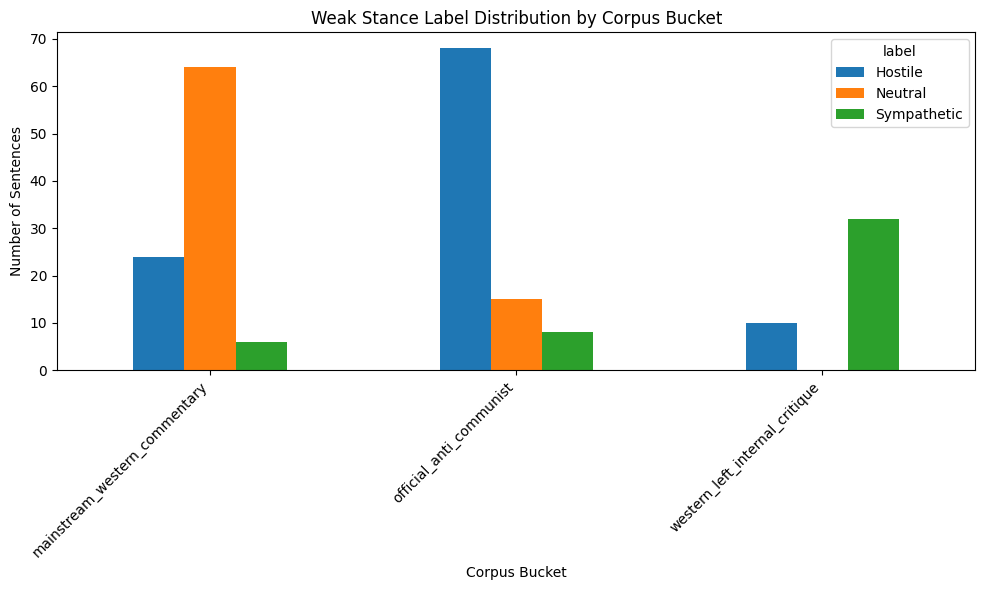

label,Hostile,Neutral,Sympathetic
bert_cluster_name,,,
Doctrinal Imagination,47,60,10
Geopolitical Mobilization,55,19,36


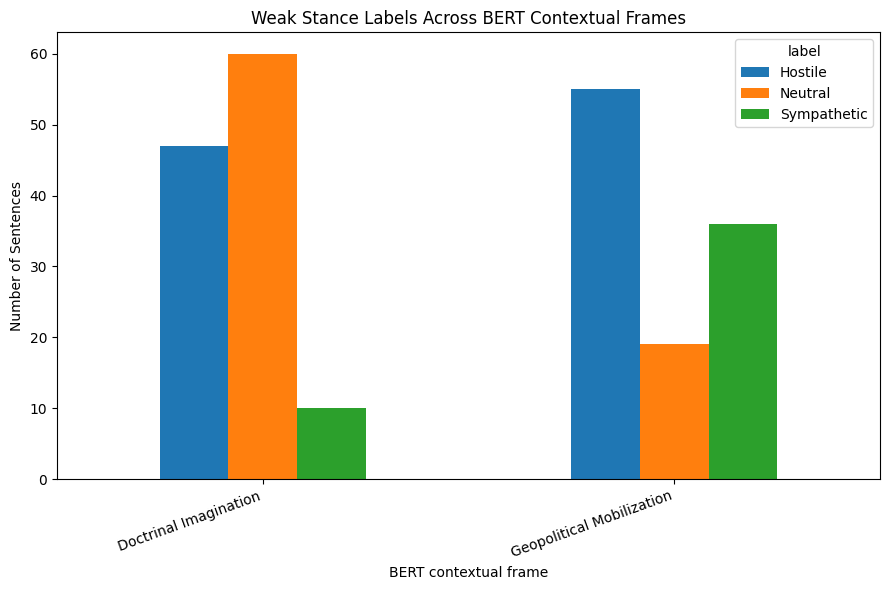


LOGISTIC REGRESSION INTERPRETATION

The classifier uses TF-IDF features to distinguish three stance-based uses of "communism": Hostile, Neutral, Sympathetic.

The top positive features for Hostile should reveal language of threat, danger, opposition, failure, coercion, or anti-communist judgment. The top features for Neutral should reveal descriptive or explanatory language. The top features for Sympathetic should reveal insider, left-theoretical, revolutionary, or pro-communist vocabulary.

Errors are meaningful because stance is not always explicit at the sentence level. Some sentences explain communism in neutral terms inside hostile documents, while others use internal left critique that may appear negative but still treats communism sympathetically as an ideal.

Accuracy: 0.614
Macro-F1: 0.556



In [23]:
# =========================
# Cell 9. Feature interpretation, prediction, and error analysis
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tfidf = pipeline.named_steps["tfidf"]
logreg = pipeline.named_steps["logreg"]

feature_names = np.array(tfidf.get_feature_names_out())
classes = logreg.classes_

# 1. Top features by label
feature_rows = []

for class_idx, class_name in enumerate(classes):
    coefs = logreg.coef_[class_idx]

    top_pos_idx = np.argsort(coefs)[-30:][::-1]
    top_neg_idx = np.argsort(coefs)[:15]

    for rank, idx in enumerate(top_pos_idx, start=1):
        feature_rows.append({
            "label": class_name,
            "direction": "positive",
            "rank": rank,
            "feature": feature_names[idx],
            "coef": coefs[idx],
        })

    for rank, idx in enumerate(top_neg_idx, start=1):
        feature_rows.append({
            "label": class_name,
            "direction": "negative",
            "rank": rank,
            "feature": feature_names[idx],
            "coef": coefs[idx],
        })

feature_df = pd.DataFrame(feature_rows)

print("Top positive features by class:")
display(
    feature_df[feature_df["direction"] == "positive"]
    .groupby("label")
    .head(15)
)

feature_df.to_csv(
    TABLE_DIR / "table_27_top_logistic_regression_features.csv",
    index=False,
    encoding="utf-8-sig"
)

# 2. Apply classifier to all sentences
df["predicted_label"] = pipeline.predict(df["sentence"].astype(str))

pred_proba = pipeline.predict_proba(df["sentence"].astype(str))
proba_df = pd.DataFrame(
    pred_proba,
    columns=[f"prob_{c}" for c in pipeline.classes_]
)

df_pred = pd.concat(
    [df.reset_index(drop=True), proba_df],
    axis=1
)

df_pred.to_csv(
    TABLE_DIR / "table_28_all_sentences_with_logreg_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

# 3. Held-out error analysis with source info
test_result = clf_df.loc[test_idx].copy()
test_result["true_label"] = y_test.values
test_result["predicted_label"] = y_pred
test_result["correct"] = test_result["true_label"] == test_result["predicted_label"]

test_proba = pipeline.predict_proba(X_test)
test_result["prediction_confidence"] = test_proba.max(axis=1)

errors = test_result[test_result["correct"] == False].copy()
errors = errors.sort_values("prediction_confidence", ascending=False)

print("Number of held-out errors:", len(errors))

display(errors[[
    "doc_id", "title", "year", "source", "bucket",
    "true_label", "predicted_label", "prediction_confidence",
    "sentence"
]].head(30))

errors.to_csv(
    TABLE_DIR / "table_29_classification_errors.csv",
    index=False,
    encoding="utf-8-sig"
)

# 4. Label by corpus bucket
label_bucket = pd.crosstab(df["bucket"], df["label"])

display(label_bucket)

label_bucket.to_csv(
    TABLE_DIR / "table_30_label_by_bucket.csv",
    encoding="utf-8-sig"
)

label_bucket.plot(kind="bar", figsize=(10, 6))
plt.title("Weak Stance Label Distribution by Corpus Bucket")
plt.xlabel("Corpus Bucket")
plt.ylabel("Number of Sentences")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_09_label_by_bucket.png", dpi=200)
plt.show()

# 5. Label by BERT named cluster, if available
if "bert_cluster_name" in df.columns:
    label_bert_named = pd.crosstab(df["bert_cluster_name"], df["label"])

    display(label_bert_named)

    label_bert_named.to_csv(
        TABLE_DIR / "table_31_label_by_bert_named_cluster.csv",
        encoding="utf-8-sig"
    )

    label_bert_named.plot(kind="bar", figsize=(9, 6))
    plt.title("Weak Stance Labels Across BERT Contextual Frames")
    plt.xlabel("BERT contextual frame")
    plt.ylabel("Number of Sentences")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig_10_label_by_bert_named_cluster.png", dpi=200)
    plt.show()

# 6. Written interpretation
feature_summary_text = f"""
LOGISTIC REGRESSION INTERPRETATION

The classifier uses TF-IDF features to distinguish three stance-based uses of "communism": {', '.join(classes)}.

The top positive features for Hostile should reveal language of threat, danger, opposition, failure, coercion, or anti-communist judgment. The top features for Neutral should reveal descriptive or explanatory language. The top features for Sympathetic should reveal insider, left-theoretical, revolutionary, or pro-communist vocabulary.

Errors are meaningful because stance is not always explicit at the sentence level. Some sentences explain communism in neutral terms inside hostile documents, while others use internal left critique that may appear negative but still treats communism sympathetically as an ideal.

Accuracy: {acc:.3f}
Macro-F1: {macro_f1:.3f}
"""

print(feature_summary_text)

with open(TEXT_DIR / "step4_feature_and_error_interpretation.txt", "w", encoding="utf-8") as f:
    f.write(feature_summary_text)

In [25]:
# =========================
# Bundle report-relevant tables into one JSON
# =========================

import json
import pandas as pd
from pathlib import Path

BUNDLE_PATH = OUT_DIR / "report_tables_bundle.json"

def read_csv_if_exists(path, n_rows=None):
    path = Path(path)
    if not path.exists():
        print("Missing:", path)
        return None
    df_tmp = pd.read_csv(path)
    if n_rows is not None:
        df_tmp = df_tmp.head(n_rows)
    return df_tmp.fillna("").to_dict(orient="records")

def read_table_if_exists(path, n_rows=None):
    path = Path(path)
    if not path.exists():
        print("Missing:", path)
        return None
    try:
        df_tmp = pd.read_csv(path)
    except Exception:
        df_tmp = pd.read_csv(path, index_col=0).reset_index()
    if n_rows is not None:
        df_tmp = df_tmp.head(n_rows)
    return df_tmp.fillna("").to_dict(orient="records")

bundle = {
    "metadata": {
        "project": "IDS 570 Term Project",
        "concept": "communism",
        "unit_of_analysis": "complete sentence containing the word communism",
        "bert_frames": [
            "Doctrinal Imagination",
            "Geopolitical Mobilization"
        ],
        "weak_supervision_labels": [
            "Hostile",
            "Neutral",
            "Sympathetic"
        ],
        "note": "This JSON bundles the core tables needed for writing the final report."
    },

    # Step 1: Data preparation
    "step1_data_preparation": {
        "dataset_summary": read_csv_if_exists(TABLE_DIR / "table_01_dataset_summary.csv"),
        "distribution_across_documents_top20": read_csv_if_exists(TABLE_DIR / "table_02_distribution_by_document.csv", n_rows=20),
        "distribution_by_bucket": read_csv_if_exists(TABLE_DIR / "table_03_distribution_by_bucket.csv"),
        "distribution_by_year": read_csv_if_exists(TABLE_DIR / "table_04_distribution_by_year.csv"),
    },

    # Step 2: NER
    "step2_named_entity_recognition": {
        "entity_type_frequency": read_csv_if_exists(TABLE_DIR / "table_06_entity_type_frequency.csv"),
        "top_focus_entities": read_csv_if_exists(TABLE_DIR / "table_07_top_focus_entities.csv", n_rows=40),
        "concept_entity_cooccurrence_examples": read_csv_if_exists(TABLE_DIR / "table_08_entity_cooccurrence_examples.csv", n_rows=30),
        "entity_type_by_label": read_csv_if_exists(TABLE_DIR / "table_09_entity_type_by_label.csv"),
        "top_entities_by_label": read_csv_if_exists(TABLE_DIR / "table_10_top_entities_by_label.csv", n_rows=40),
    },

    # Step 3: BERT contextual meaning
    "step3_bert_contextual_meaning": {
        "bert_cluster_counts": read_csv_if_exists(TABLE_DIR / "table_19_bert_cluster_name_counts.csv"),
        "bert_named_cluster_representative_examples": read_csv_if_exists(TABLE_DIR / "table_20_bert_named_cluster_representative_examples.csv", n_rows=30),
        "bert_named_cluster_by_bucket": read_csv_if_exists(TABLE_DIR / "table_21_bert_named_cluster_by_bucket.csv"),
        "bert_named_cluster_by_source": read_csv_if_exists(TABLE_DIR / "table_22_bert_named_cluster_by_source.csv"),
        "bert_named_cluster_year_summary": read_csv_if_exists(TABLE_DIR / "table_23_bert_named_cluster_year_summary.csv"),
    },

    # Step 4: Classification
    "step4_weak_supervision_classification": {
        "label_distribution": read_csv_if_exists(TABLE_DIR / "table_24_label_distribution.csv"),
        "classification_report": read_csv_if_exists(TABLE_DIR / "table_25_classification_report.csv"),
        "confusion_matrix": read_csv_if_exists(TABLE_DIR / "table_26_confusion_matrix.csv"),
        "top_logistic_regression_features": read_csv_if_exists(TABLE_DIR / "table_27_top_logistic_regression_features.csv", n_rows=90),
        "classification_error_examples": read_csv_if_exists(TABLE_DIR / "table_29_classification_errors.csv", n_rows=30),
        "stance_label_by_bucket": read_csv_if_exists(TABLE_DIR / "table_30_label_by_bucket.csv"),
        "stance_label_by_bert_frame": read_csv_if_exists(TABLE_DIR / "table_31_label_by_bert_named_cluster.csv"),
    },

    # Main figures to reference in report
    "recommended_figures": {
        "occurrences_by_document": str(FIG_DIR / "fig_01_occurrences_by_document.png"),
        "occurrences_by_year": str(FIG_DIR / "fig_02_occurrences_by_year.png"),
        "occurrences_by_bucket": str(FIG_DIR / "fig_03_occurrences_by_bucket.png"),
        "entity_type_frequency": str(FIG_DIR / "fig_04_entity_type_frequency.png"),
        "bert_pca_clusters": str(FIG_DIR / "fig_06_bert_pca_clusters.png"),
        "bert_named_cluster_counts": str(FIG_DIR / "fig_07_bert_named_cluster_counts.png"),
        "confusion_matrix": str(FIG_DIR / "fig_08_confusion_matrix.png"),
        "stance_label_by_bucket": str(FIG_DIR / "fig_09_label_by_bucket.png"),
        "stance_label_by_bert_frame": str(FIG_DIR / "fig_10_label_by_bert_named_cluster.png"),
    }
}

with open(BUNDLE_PATH, "w", encoding="utf-8") as f:
    json.dump(bundle, f, ensure_ascii=False, indent=2)

print("Saved JSON bundle:")
print(BUNDLE_PATH)

# Quick preview
print("\nTop-level keys:")
print(list(bundle.keys()))

print("\nClassification report preview:")
print(json.dumps(bundle["step4_weak_supervision_classification"]["classification_report"], ensure_ascii=False, indent=2)[:1500])

Missing: /root/autodl-tmp/ids570_term_project/final_outputs/tables/table_10_top_entities_by_label.csv
Saved JSON bundle:
/root/autodl-tmp/ids570_term_project/final_outputs/report_tables_bundle.json

Top-level keys:
['metadata', 'step1_data_preparation', 'step2_named_entity_recognition', 'step3_bert_contextual_meaning', 'step4_weak_supervision_classification', 'recommended_figures']

Classification report preview:
[
  {
    "label": "Hostile",
    "precision": 0.6428571428571429,
    "recall": 0.6923076923076923,
    "f1-score": 0.6666666666666666,
    "support": 26.0
  },
  {
    "label": "Neutral",
    "precision": 0.6363636363636364,
    "recall": 0.7,
    "f1-score": 0.6666666666666666,
    "support": 20.0
  },
  {
    "label": "Sympathetic",
    "precision": 0.4285714285714285,
    "recall": 0.2727272727272727,
    "f1-score": 0.3333333333333333,
    "support": 11.0
  },
  {
    "label": "accuracy",
    "precision": 0.6140350877192983,
    "recall": 0.6140350877192983,
    "f1-scor

# Current Paper Figures

,paper_figure_no,filename,path,label,status
0,1,fig1_entity_type_frequency.png,/root/autodl-tmp/ids570_term_project/final_out...,fig:nerfreq,EXISTS
1,2,fig2_top_focus_entities.png,/root/autodl-tmp/ids570_term_project/final_out...,fig:topentities,EXISTS
2,3,fig3_bert_pca_clusters.png,/root/autodl-tmp/ids570_term_project/final_out...,fig:bertpca,EXISTS
3,4,fig4_stance_by_bucket.png,/root/autodl-tmp/ids570_term_project/final_out...,fig:bucketstance,EXISTS
4,5,fig5_stance_by_bert_frame.png,/root/autodl-tmp/ids570_term_project/final_out...,fig:stancebert,EXISTS
5,6,fig6_confusion_matrix.png,/root/autodl-tmp/ids570_term_project/final_out...,fig:confusion,EXISTS


## Figure 1: `fig1_entity_type_frequency.png`

**Label:** `fig:nerfreq`

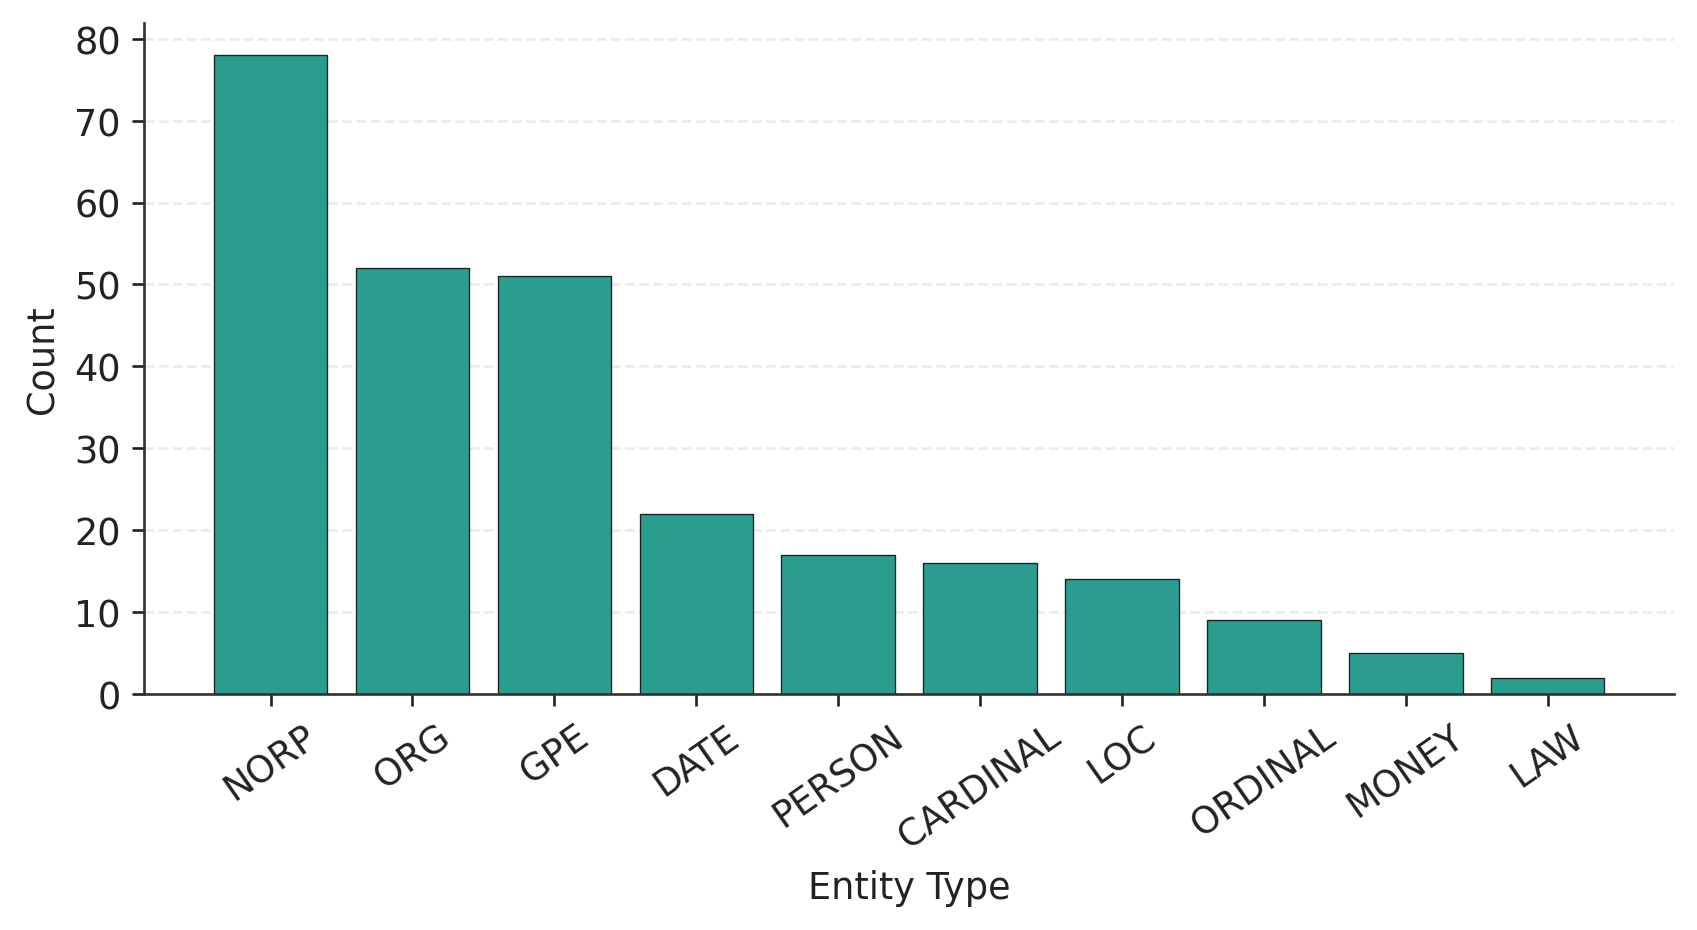

## Figure 2: `fig2_top_focus_entities.png`

**Label:** `fig:topentities`

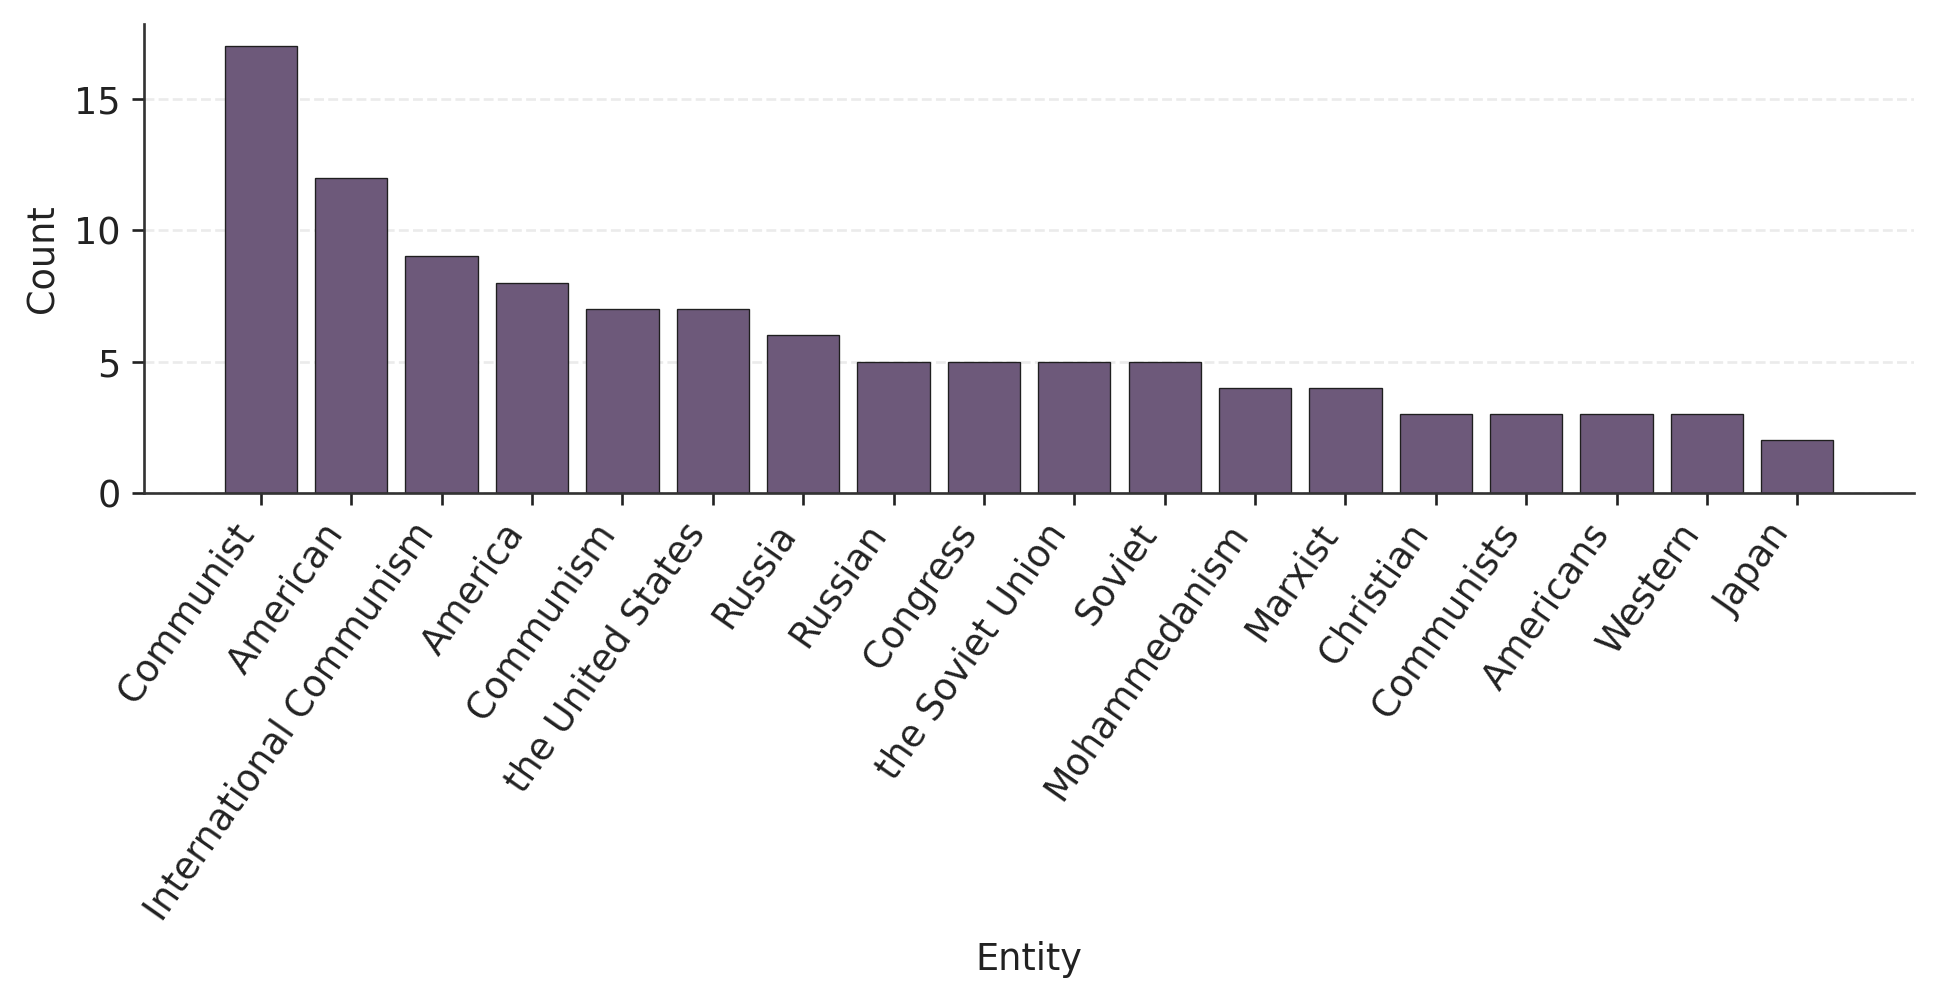

## Figure 3: `fig3_bert_pca_clusters.png`

**Label:** `fig:bertpca`

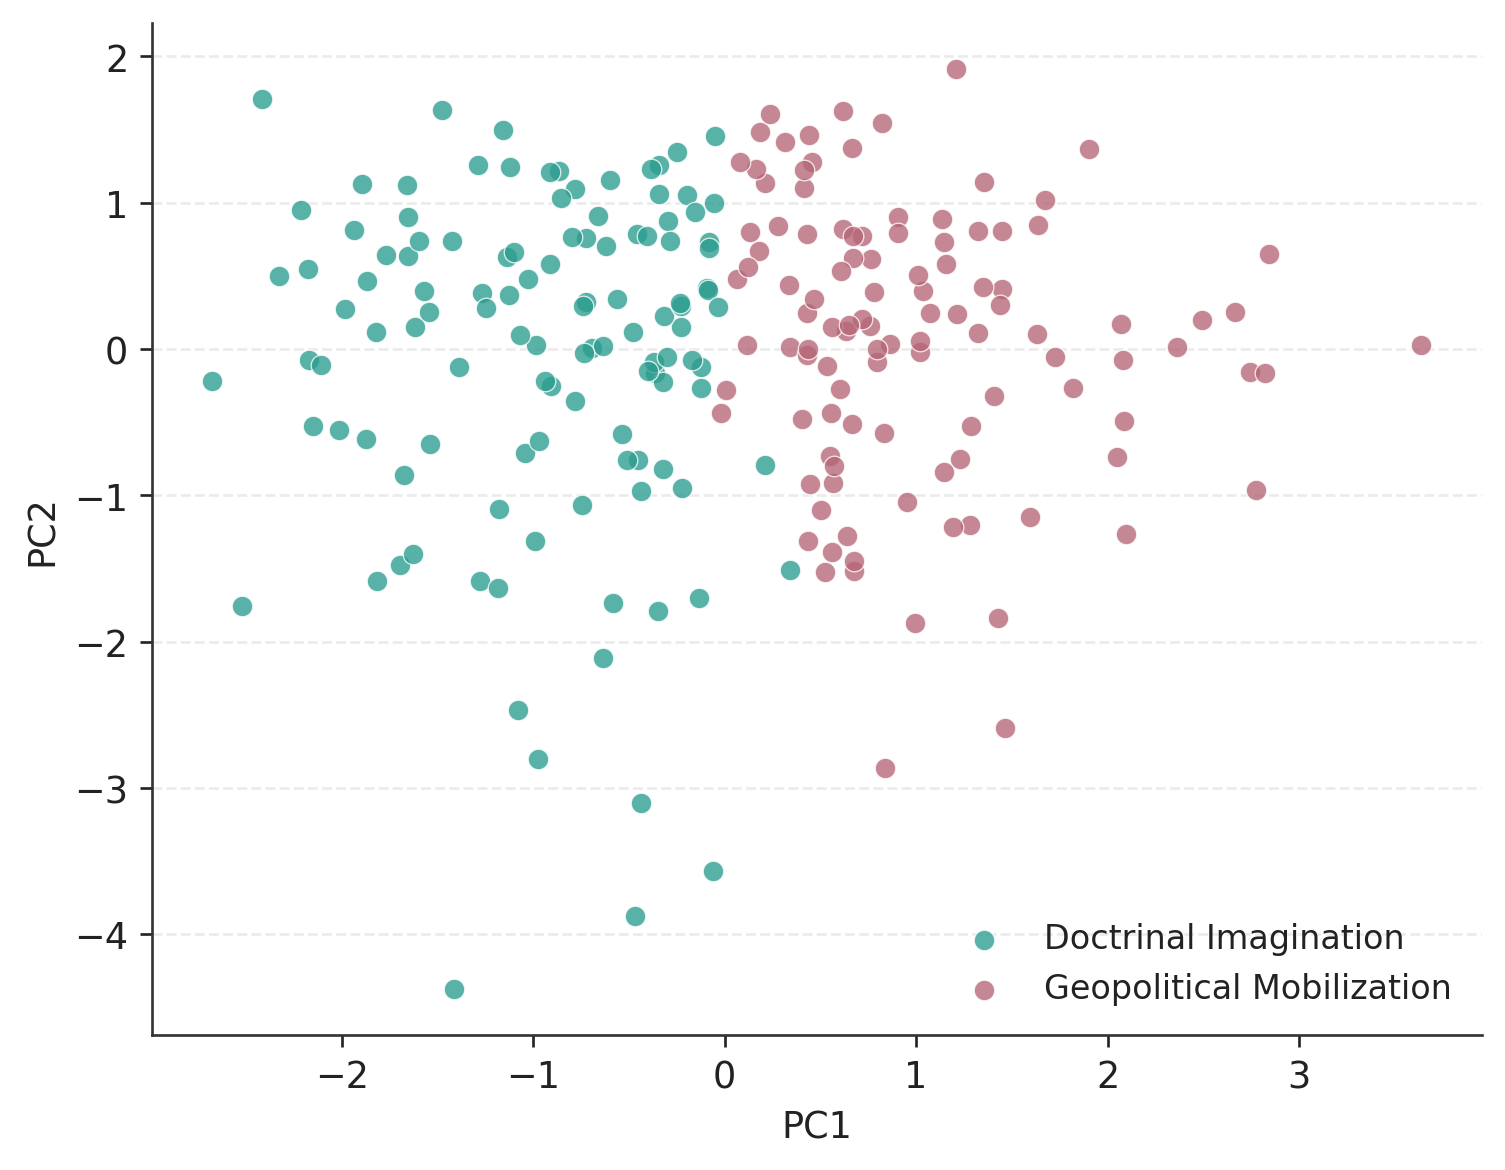

## Figure 4: `fig4_stance_by_bucket.png`

**Label:** `fig:bucketstance`

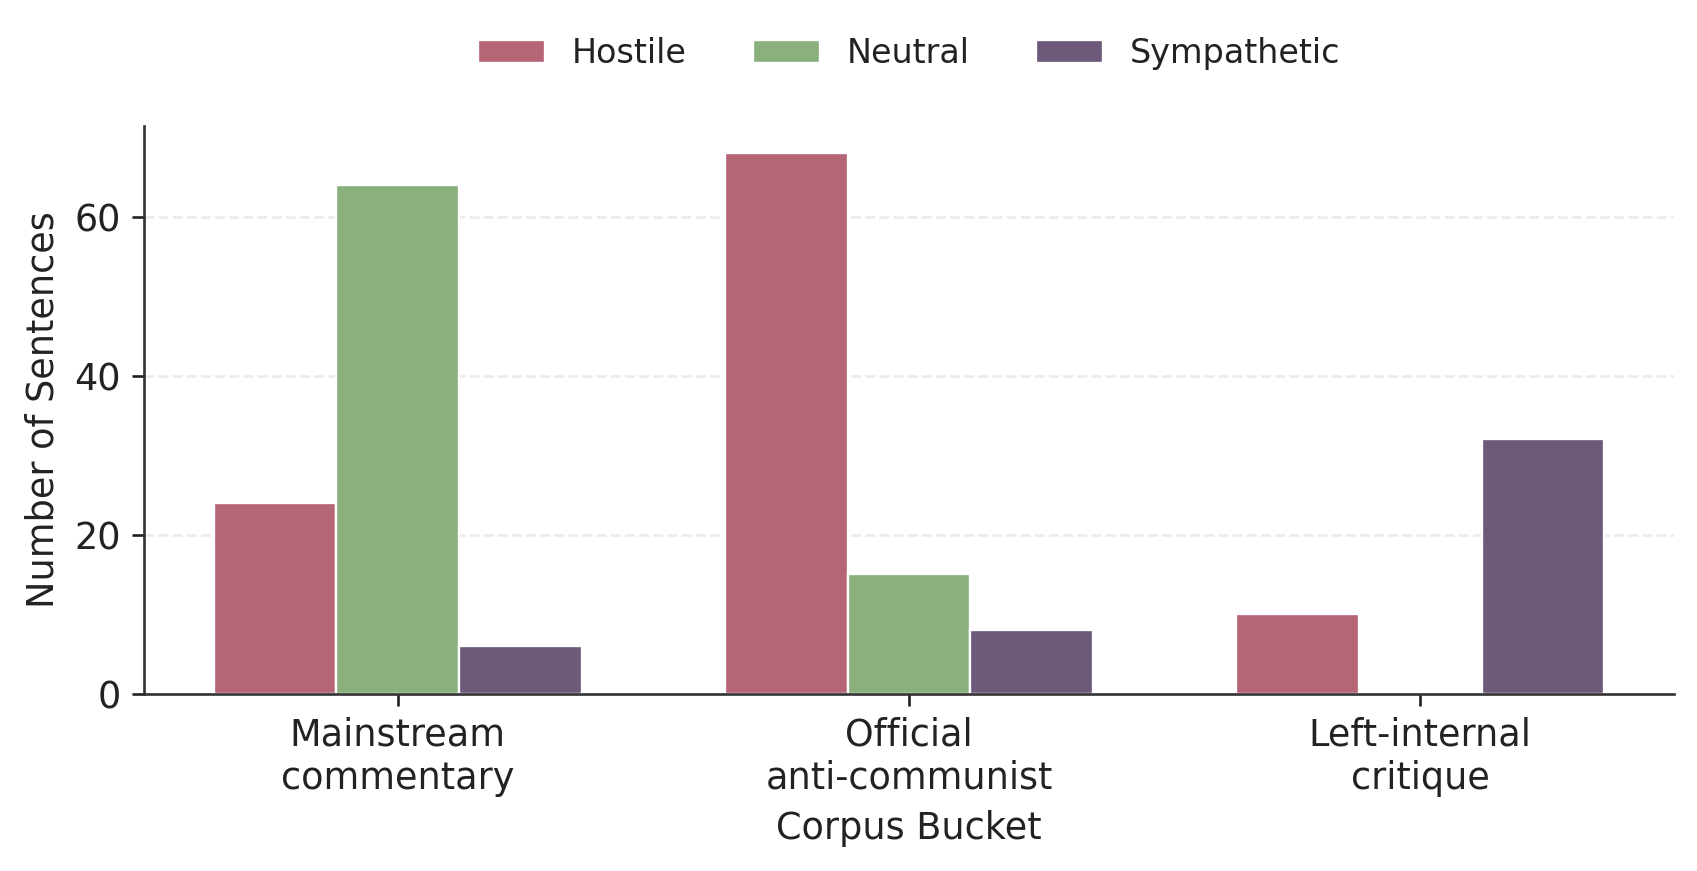

## Figure 5: `fig5_stance_by_bert_frame.png`

**Label:** `fig:stancebert`

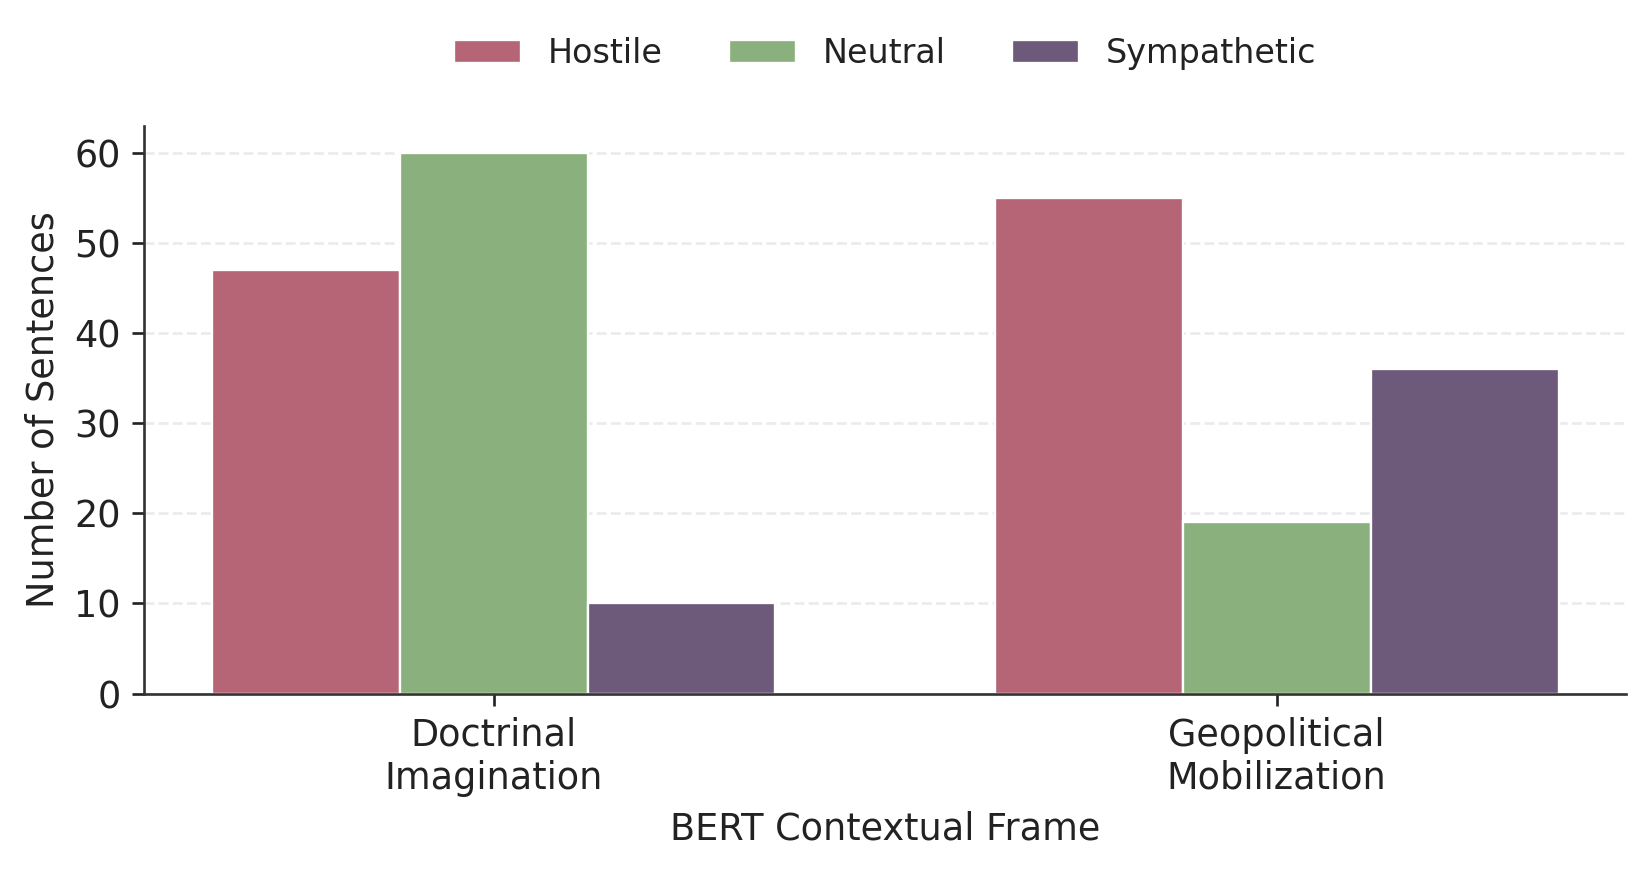

## Figure 6: `fig6_confusion_matrix.png`

**Label:** `fig:confusion`

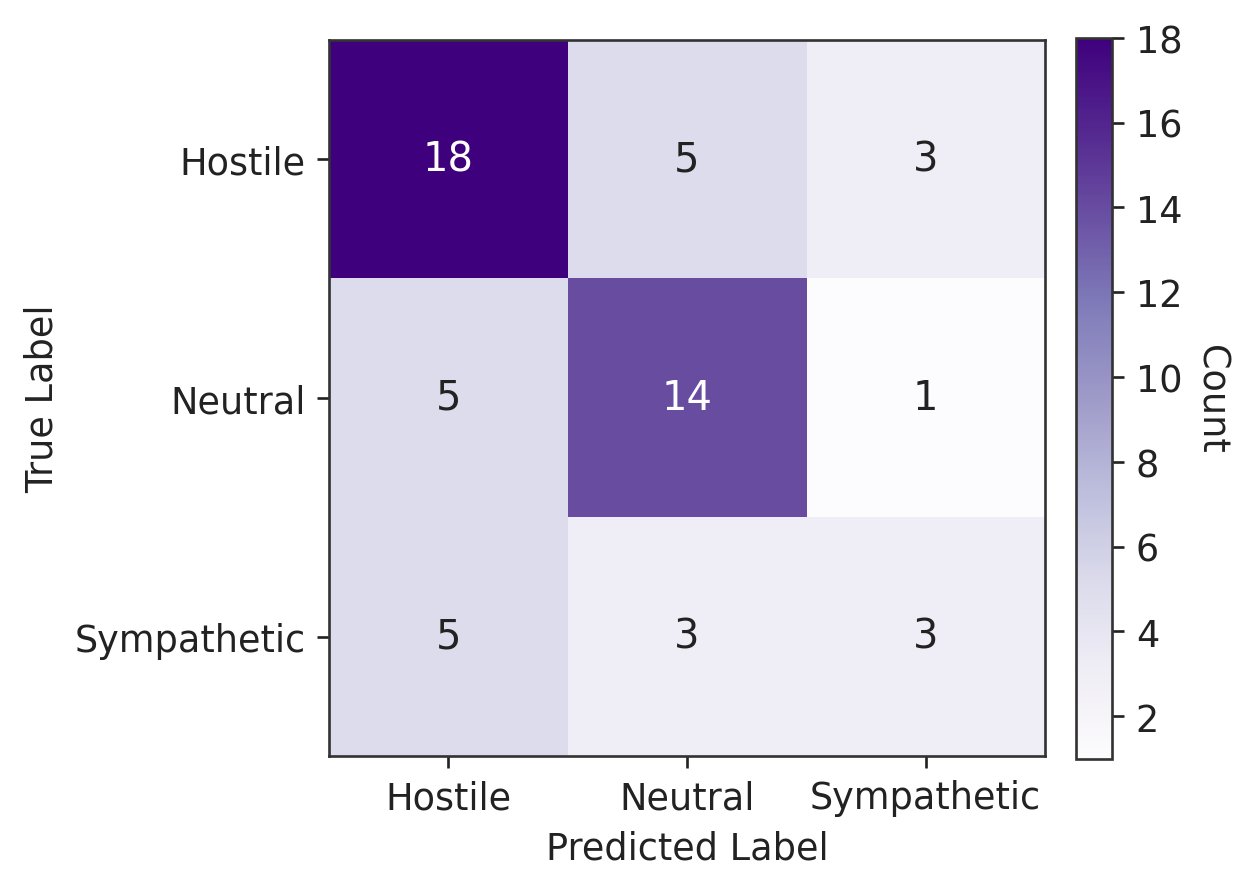

# Updated LaTeX Figure Blocks

% Figure 1
\begin{figure}[!htbp]
\centering
\includegraphics[width=0.70\linewidth]{paper_figures/fig1_entity_type_frequency.png}
\caption{Named entity type frequency in sentences containing \concept{}. NORP, ORG, and GPE dominate, suggesting that the concept is repeatedly constructed through political group identity, institutions, and geopolitical space.}
\label{fig:nerfreq}
\end{figure}

% Figure 2
\begin{figure}[!htbp]
\centering
\includegraphics[width=0.72\linewidth]{paper_figures/fig2_top_focus_entities.png}
\caption{Top PERSON/GPE/ORG/NORP entities near \concept{}. The most frequent entities point toward a discourse organized around American identity, Soviet power, international communism, and communist political identity.}
\label{fig:topentities}
\end{figure}

% Figure 3
\begin{figure}[!htbp]
\centering
\includegraphics[width=0.72\linewidth]{paper_figures/fig3_bert_pca_clusters.png}
\caption{PCA projection of BERT sentence embeddings, colored by contextual frame. The two groups w

In [37]:
# =========================
# Final Paper Figures — NO INTERNAL TITLES
# - Original bucket distribution and BERT frame count are tables in the paper, not figures.
# - Regenerates the remaining 6 paper figures.
# - No ax.set_title anywhere: captions in LaTeX serve as figure titles.
# - Figure 4 / 5 keep grouped-bar format, only recolored.
# =========================

from pathlib import Path
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path("/root/autodl-tmp/ids570_term_project")
TABLE_DIR = ROOT / "final_outputs" / "tables"
FIG_DIR = ROOT / "final_outputs" / "figures"
PAPER_FIG_DIR = ROOT / "final_outputs" / "paper_figures"
PAPER_FIG_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Pretty color settings
# -------------------------
COLORS = {
    "navy": "#2F3A56",
    "slate": "#4C5B73",
    "teal": "#2A9D8F",
    "sage": "#8AB17D",
    "gold": "#E9C46A",
    "coral": "#E76F51",
    "rose": "#B56576",
    "plum": "#6D597A",
    "cream": "#F7F3E8",
    "gray": "#6C757D",
}

STANCE_COLORS = {
    "Hostile": "#B56576",
    "Neutral": "#8AB17D",
    "Sympathetic": "#6D597A",
}

BERT_COLORS = {
    "Doctrinal Imagination": "#2A9D8F",
    "Geopolitical Mobilization": "#B56576",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "text.color": "#222222",
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

def beautify_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

def savefig(path, rect=None):
    if rect is None:
        plt.tight_layout()
    else:
        plt.tight_layout(rect=rect)
    plt.savefig(path, dpi=240, bbox_inches="tight")
    plt.close()

# =========================
# Figure 1: Entity type frequency
# =========================

entity_freq_path = TABLE_DIR / "table_06_entity_type_frequency.csv"
fig1_path = PAPER_FIG_DIR / "fig1_entity_type_frequency.png"

entity_freq = pd.read_csv(entity_freq_path).head(10)

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.bar(
    entity_freq["entity_type"],
    entity_freq["count"],
    color=COLORS["teal"],
    edgecolor="#1F1F1F",
    linewidth=0.4
)
ax.set_xlabel("Entity Type")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=35)
beautify_axes(ax)
savefig(fig1_path)

# =========================
# Figure 2: Top focus entities
# =========================

top_entities_candidates = [
    TABLE_DIR / "table_07_top_focus_entities.csv",
    TABLE_DIR / "table_07b_top10_entities_by_type.csv",
]
top_entities_path = next((p for p in top_entities_candidates if p.exists()), None)
if top_entities_path is None:
    raise FileNotFoundError("Cannot find top focus entity table.")

top_entities = pd.read_csv(top_entities_path)

if "entity_text_clean" in top_entities.columns:
    entity_col = "entity_text_clean"
elif "entity_text" in top_entities.columns:
    entity_col = "entity_text"
else:
    raise ValueError(f"No entity text column found. Columns: {top_entities.columns.tolist()}")

top_entities_plot = (
    top_entities.groupby(entity_col)["count"]
    .sum()
    .reset_index()
    .sort_values("count", ascending=False)
    .head(18)
)

fig2_path = PAPER_FIG_DIR / "fig2_top_focus_entities.png"

fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(
    top_entities_plot[entity_col].astype(str),
    top_entities_plot["count"],
    color=COLORS["plum"],
    edgecolor="#1F1F1F",
    linewidth=0.4
)
ax.set_xlabel("Entity")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=55)
for label in ax.get_xticklabels():
    label.set_ha("right")
beautify_axes(ax)
savefig(fig2_path)

# =========================
# Figure 3: BERT PCA clusters
# =========================

fig3_path = PAPER_FIG_DIR / "fig3_bert_pca_clusters.png"

can_regen_pca = (
    "X" in globals()
    and "df" in globals()
    and ("bert_cluster_name" in df.columns or "bert_cluster_2" in df.columns)
)

if can_regen_pca:
    from sklearn.decomposition import PCA

    pca = PCA(n_components=2, random_state=3407)
    X_pca = pca.fit_transform(X)

    pca_df = df.copy()
    pca_df["pc1"] = X_pca[:, 0]
    pca_df["pc2"] = X_pca[:, 1]

    if "bert_cluster_name" not in pca_df.columns and "bert_cluster_2" in pca_df.columns:
        pca_df["bert_cluster_name"] = pca_df["bert_cluster_2"].map({
            0: "Doctrinal Imagination",
            1: "Geopolitical Mobilization",
        })

    fig, ax = plt.subplots(figsize=(6.4, 5.0))

    for name, sub in pca_df.groupby("bert_cluster_name"):
        ax.scatter(
            sub["pc1"],
            sub["pc2"],
            s=38,
            alpha=0.78,
            label=name,
            color=BERT_COLORS.get(name, COLORS["slate"]),
            edgecolor="white",
            linewidth=0.4
        )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(frameon=False, loc="best")
    beautify_axes(ax)
    savefig(fig3_path)

else:
    old_pca = FIG_DIR / "fig_06_bert_pca_clusters.png"
    if old_pca.exists():
        shutil.copy2(old_pca, fig3_path)
    else:
        raise FileNotFoundError("Cannot regenerate or copy BERT PCA figure.")

# =========================
# Figure 4: Stance by corpus bucket
# Grouped bar, no title
# =========================

bucket_path_candidates = [
    TABLE_DIR / "table_30_label_by_bucket.csv",
    TABLE_DIR / "table_31_stance_label_by_bucket.csv",
]
bucket_path = next((p for p in bucket_path_candidates if p.exists()), None)
if bucket_path is None:
    raise FileNotFoundError("Cannot find stance-by-bucket table.")

bucket_df = pd.read_csv(bucket_path)

if "bucket" not in bucket_df.columns:
    first_col = bucket_df.columns[0]
    bucket_df = bucket_df.rename(columns={first_col: "bucket"})

stance_cols = [c for c in ["Hostile", "Neutral", "Sympathetic"] if c in bucket_df.columns]
bucket_df = bucket_df[["bucket"] + stance_cols].copy()

bucket_name_map = {
    "mainstream_western_commentary": "Mainstream\ncommentary",
    "official_anti_communist": "Official\nanti-communist",
    "western_left_internal_critique": "Left-internal\ncritique",
}
bucket_df["bucket_pretty"] = bucket_df["bucket"].map(bucket_name_map).fillna(bucket_df["bucket"])

fig4_path = PAPER_FIG_DIR / "fig4_stance_by_bucket.png"

x = np.arange(len(bucket_df))
width = 0.24

fig, ax = plt.subplots(figsize=(7.2, 4.25))

for i, col in enumerate(stance_cols):
    ax.bar(
        x + (i - 1) * width,
        bucket_df[col].values,
        width=width,
        label=col,
        color=STANCE_COLORS.get(col, COLORS["gray"]),
        edgecolor="#FFFFFF",
        linewidth=0.7
    )

ax.set_xticks(x)
ax.set_xticklabels(bucket_df["bucket_pretty"])
ax.set_xlabel("Corpus Bucket")
ax.set_ylabel("Number of Sentences")
ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    borderaxespad=0.0
)
beautify_axes(ax)
savefig(fig4_path, rect=[0, 0, 1, 0.92])

# =========================
# Figure 5: Stance by BERT frame
# Grouped bar, no title
# =========================

bert_stance_candidates = [
    TABLE_DIR / "table_31_label_by_bert_named_cluster.csv",
    TABLE_DIR / "table_32_stance_label_by_bert_named_cluster.csv",
]
bert_stance_path = next((p for p in bert_stance_candidates if p.exists()), None)
if bert_stance_path is None:
    raise FileNotFoundError("Cannot find stance-by-BERT-frame table.")

bert_stance = pd.read_csv(bert_stance_path)

if "bert_cluster_name" not in bert_stance.columns:
    first_col = bert_stance.columns[0]
    bert_stance = bert_stance.rename(columns={first_col: "bert_cluster_name"})

stance_cols = [c for c in ["Hostile", "Neutral", "Sympathetic"] if c in bert_stance.columns]
bert_stance = bert_stance[["bert_cluster_name"] + stance_cols].copy()

bert_stance["frame_pretty"] = bert_stance["bert_cluster_name"].replace({
    "Doctrinal Imagination": "Doctrinal\nImagination",
    "Geopolitical Mobilization": "Geopolitical\nMobilization",
})

fig5_path = PAPER_FIG_DIR / "fig5_stance_by_bert_frame.png"

x = np.arange(len(bert_stance))
width = 0.24

fig, ax = plt.subplots(figsize=(7.0, 4.25))

for i, col in enumerate(stance_cols):
    ax.bar(
        x + (i - 1) * width,
        bert_stance[col].values,
        width=width,
        label=col,
        color=STANCE_COLORS.get(col, COLORS["gray"]),
        edgecolor="#FFFFFF",
        linewidth=0.7
    )

ax.set_xticks(x)
ax.set_xticklabels(bert_stance["frame_pretty"])
ax.set_xlabel("BERT Contextual Frame")
ax.set_ylabel("Number of Sentences")
ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    borderaxespad=0.0
)
beautify_axes(ax)
savefig(fig5_path, rect=[0, 0, 1, 0.92])

# =========================
# Figure 6: Confusion matrix
# =========================

cm_candidates = [
    TABLE_DIR / "table_26_confusion_matrix.csv",
    TABLE_DIR / "table_27_confusion_matrix_stance.csv",
]
cm_path = next((p for p in cm_candidates if p.exists()), None)
if cm_path is None:
    raise FileNotFoundError("Cannot find confusion matrix table.")

cm_df = pd.read_csv(cm_path)
first_col = cm_df.columns[0]
cm_df = cm_df.rename(columns={first_col: "true_label"})

cm_df["true_label"] = cm_df["true_label"].astype(str).str.replace("true_", "", regex=False)
pred_cols = [c for c in cm_df.columns if c.startswith("pred_")]
clean_pred_cols = [c.replace("pred_", "") for c in pred_cols]

cm_values = cm_df[pred_cols].values
true_labels = cm_df["true_label"].tolist()
pred_labels = clean_pred_cols

fig6_path = PAPER_FIG_DIR / "fig6_confusion_matrix.png"

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm_values, cmap="Purples")

ax.set_xticks(np.arange(len(pred_labels)))
ax.set_yticks(np.arange(len(true_labels)))
ax.set_xticklabels(pred_labels)
ax.set_yticklabels(true_labels)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

for i in range(cm_values.shape[0]):
    for j in range(cm_values.shape[1]):
        value = cm_values[i, j]
        ax.text(
            j, i, str(value),
            ha="center", va="center",
            color="white" if value > cm_values.max() * 0.55 else "#222222",
            fontsize=12
        )

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Count", rotation=270, labelpad=14)

plt.tight_layout()
plt.savefig(fig6_path, dpi=240, bbox_inches="tight")
plt.close()

# =========================
# Display final figures directly in notebook panel
# =========================

paper_figures = [
    {"no": 1, "path": fig1_path, "label": "fig:nerfreq"},
    {"no": 2, "path": fig2_path, "label": "fig:topentities"},
    {"no": 3, "path": fig3_path, "label": "fig:bertpca"},
    {"no": 4, "path": fig4_path, "label": "fig:bucketstance"},
    {"no": 5, "path": fig5_path, "label": "fig:stancebert"},
    {"no": 6, "path": fig6_path, "label": "fig:confusion"},
]

fig_map = pd.DataFrame([
    {
        "paper_figure_no": item["no"],
        "filename": item["path"].name,
        "path": str(item["path"]),
        "label": item["label"],
        "status": "EXISTS" if item["path"].exists() else "MISSING",
    }
    for item in paper_figures
])

mapping_path = PAPER_FIG_DIR / "current_paper_figure_mapping.csv"
fig_map.to_csv(mapping_path, index=False, encoding="utf-8-sig")

display(Markdown("# Current Paper Figures"))
display(fig_map)

for item in paper_figures:
    display(Markdown(f"## Figure {item['no']}: `{item['path'].name}`"))
    display(Markdown(f"**Label:** `{item['label']}`"))
    display(Image(filename=str(item["path"])))

# =========================
# Print updated LaTeX blocks
# =========================

display(Markdown("# Updated LaTeX Figure Blocks"))

latex_width = {
    1: "0.70",
    2: "0.72",
    3: "0.72",
    4: "0.72",
    5: "0.72",
    6: "0.62",
}

latex_caption = {
    1: r"Named entity type frequency in sentences containing \concept{}. NORP, ORG, and GPE dominate, suggesting that the concept is repeatedly constructed through political group identity, institutions, and geopolitical space.",
    2: r"Top PERSON/GPE/ORG/NORP entities near \concept{}. The most frequent entities point toward a discourse organized around American identity, Soviet power, international communism, and communist political identity.",
    3: r"PCA projection of BERT sentence embeddings, colored by contextual frame. The two groups were named only after reading representative examples, not from weak labels.",
    4: r"Weak stance labels by corpus bucket. Official anti-communist discourse concentrates hostile uses; mainstream commentary concentrates neutral explanation; left-internal critique concentrates sympathetic or insider framings.",
    5: r"Weak stance labels across BERT contextual frames. \frameA{} is more explanatory and moral-philosophical; \frameB{} is more polarized, containing both hostile Cold War framing and sympathetic left-internal mobilization.",
    6: r"Confusion matrix for TF--IDF logistic regression. The model performs best on \hostile{} and \neutral{} examples, while \sympathetic{} is frequently confused with the other labels.",
}

for item in paper_figures:
    no = item["no"]
    rel_path = f"paper_figures/{item['path'].name}"
    print(f"% Figure {no}")
    print(r"\begin{figure}[!htbp]")
    print(r"\centering")
    print(rf"\includegraphics[width={latex_width[no]}\linewidth]{{{rel_path}}}")
    print(rf"\caption{{{latex_caption[no]}}}")
    print(rf"\label{{{item['label']}}}")
    print(r"\end{figure}")
    print()

print("Saved polished figures to:", PAPER_FIG_DIR)
print("Saved mapping CSV:", mapping_path)